# UNet - пайплайн экспериментов и финального обучения: SAR Oil Spill Segmentation

**Исполнитель:** Никитина Дарья Дмитриевна

Этот ноутбук подбирает гиперпараметры обучения для архитектуры UNet и проводит финальное обучение. Все условия, зафиксированные ранее в `shared_config.json` для честного сравнения архитектур (размер патча, нормализация, split, оверсэмплинг, аугментаций нет, loss BCE+Dice с bce_weight=0.64, pos_weight=23), используются как есть и **не перебираются**.

Структура ноутбука:

| Раздел | Что делаем | Результат |
|---|---|---|
| Общая настройка | Пути, датасет, модель, loss, метрика, цикл обучения, чекпоинты | Базовые функции для всех стадий |
| Стадия 1 | Optuna-поиск: optimizer + lr + scheduler + weight_decay (10 trials, 7 эпох) | Топ-3 конфигурации |
| Стадия 2 | Топ-3 конфигурации обучаются по 15 эпох (отдельные ячейки) | Конфигурация-победитель |
| Стадия 3 | Multi-seed проверка победителя (15 эпох х 3 seed) | Устойчивая итоговая конфигурация |
| Финал | Обучение на 50 эпохах с чекпоинтами | `final_model.pth` |


## Блок 1: Общая настройка

In [2]:
!pip install segmentation-models-pytorch -q

In [3]:
# Импорты
import os
import time
import shutil
import random
import glob
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

import rasterio
from rasterio.windows import Window
import json

import segmentation_models_pytorch as smp

import optuna
from optuna.pruners import MedianPruner

from IPython.display import FileLink, display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [4]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [5]:
# Воспроизводимость: seed=42 везде
SEED = 42 
random.seed(SEED); np.random.seed(SEED) # фиксация для Python, NumPy
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED) # фиксация для инициализации весов на CPU, GPU
torch.backends.cudnn.deterministic = True # фиксация для детерменирвоанных алгоритмов свёртки
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED) # фиксация хэширования 

In [6]:
# Подгрузка данных
DATA_PARTS = {
    'part1': "/kaggle/input/datasets/daryanikitina/sar-oil-spill-part1",
    'part2': "/kaggle/input/datasets/daryanikitina/sar-oil-spill-part2",
    'part3': "/kaggle/input/datasets/daryanikitina/sar-oil-spill-part3",
}

# Пути к готовым CSV-инвентарям (train/val)
TRAIN_CSV = "/kaggle/input/datasets/nd010604/splits-new/train_patch_inventory.csv"
VAL_CSV = "/kaggle/input/datasets/nd010604/splits-new/val_patch_inventory.csv"

# Загружаю shared_config.json - единые параметры, зафиксированные для всех архитектур
SHARED_CONFIG_PATH = '/kaggle/input/datasets/nd010604/splits-new/shared_config.json'

with open(SHARED_CONFIG_PATH, 'r', encoding='utf-8') as f:
    shared_config = json.load(f)

print('Загружен shared_config.json:')
print(json.dumps(shared_config, indent=2, ensure_ascii=False))

# Статистики z-score нормализации, посчитанные на train (из shared_config)
NORM_STATS = dict(
    vv_mean=shared_config['norm_stats']['VV_mean'],
    vv_std=shared_config['norm_stats']['VV_std'],
    vh_mean=shared_config['norm_stats']['VH_mean'],
    vh_std=shared_config['norm_stats']['VH_std'],
)

# Технические константы
BATCH_SIZE = 8
NUM_WORKERS = 2

# Размер патча
PATCH_SIZE = shared_config['PATCH_SIZE']

# Параметры loss-функции BCE+Dice (из shared_config, подобраны отдельным Optuna-экспериментом)
BCE_WEIGHT = shared_config['BEST_LOSS_PARAMS']['bce_weight']
POS_WEIGHT = shared_config['BEST_LOSS_PARAMS']['pos_weight']

Загружен shared_config.json:
{
  "PATCH_SIZE": 512,
  "norm_stats": {
    "VV_mean": -31.315275,
    "VV_std": 7.87874,
    "VH_mean": -19.719892,
    "VH_std": 6.16873
  },
  "OVERSAMPLE_RATIO": "1:1",
  "BEST_AUG": "aug_v1",
  "BEST_AUG_DESCRIPTION": "Без аугментаций - только перевод в тензор (ToTensorV2)",
  "BEST_LOSS": "bce_dice",
  "BEST_LOSS_PARAMS": {
    "bce_weight": 0.6391963650868431,
    "pos_weight": 22.959754525911098
  }
}


In [7]:
# Dataset
class OilSpillPatchDataset(Dataset):
    """
    Один элемент инвентаря = одно окно (Window) 512x512 в большом .tif снимке.
    Читает VV и VH каналы (в дБ) + маску, применяет z-score нормализацию.
    """
    def __init__(self, inventory_df, norm_stats):
        self.df = inventory_df.reset_index(drop=True)
        self.norm_stats = norm_stats

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        window = Window(row['col'], row['row'], PATCH_SIZE, PATCH_SIZE)

        with rasterio.open(row['image_path']) as src:
            img = src.read(window=window).astype('float32')  # (2, H, W)

        with rasterio.open(row['mask_path']) as src:
            mask = src.read(1, window=window).astype('float32')  # (H, W)

        # Паддинг до PATCH_SIZE х PATCH_SIZE если патч на краю снимка оказался меньше
        # (rasterio читает сколько есть, не добивая нулями автоматически)
        c, h, w = img.shape
        if h != PATCH_SIZE or w != PATCH_SIZE:
            padded_img = np.zeros((c, PATCH_SIZE, PATCH_SIZE), dtype='float32')
            padded_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype='float32')
            padded_img[:, :h, :w] = img
            padded_mask[:h, :w] = mask
            img, mask = padded_img, padded_mask

        # z-score нормализация раздельно по VV и VH
        img[0] = (img[0] - self.norm_stats['vv_mean']) / self.norm_stats['vv_std']
        img[1] = (img[1] - self.norm_stats['vh_mean']) / self.norm_stats['vh_std']

        img_t = torch.from_numpy(img)
        mask_t = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)
        return img_t, mask_t


def build_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_df = pd.read_csv(TRAIN_CSV)
    val_df = pd.read_csv(VAL_CSV)

    train_ds = OilSpillPatchDataset(train_df, NORM_STATS)
    val_ds = OilSpillPatchDataset(val_df, NORM_STATS)

    # Оверсэмплинг 1:1 — положительные патчи сэмплируются с тем же весом, что и отрицательные
    n_pos = train_df['has_oil'].sum()
    n_neg = len(train_df) - n_pos
    weights = train_df['has_oil'].map({1: n_neg / n_pos, 0: 1.0}).values
    sampler = WeightedRandomSampler(weights, num_samples=2 * int(n_neg), replacement=True)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler,
        num_workers=num_workers, persistent_workers=True, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, persistent_workers=True, pin_memory=True,
    )
    return train_loader, val_loader

In [8]:
# Модель
def build_model():
    """
    UNet, encoder=resnet34, encoder_weights=None (без ImageNet pretrained -
    SAR в дБ принципиально отличается от RGB). in_channels=2 (VV, VH), classes=1.
    """
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights=None,
        in_channels=2,
        classes=1,
    )
    return model.to(DEVICE)

In [9]:
# Loss: BCE + Dice (зафиксировано в shared_config, не перебираю)
class BCEDiceLoss(nn.Module):
    """
    bce_weight - доля BCE в итоговом loss, (1 - bce_weight) - доля Dice.
    pos_weight - вес положительного класса (нефть) в BCE, компенсирует дисбаланс в 5% пикселей.
    """
    def __init__(self, bce_weight=BCE_WEIGHT, pos_weight=POS_WEIGHT, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

In [10]:
# Метрика мониторинга: val_oil_iou (порог фиксирован 0.5 для мониторинга по эпохам;
# финальный подбор порога на val - отдельная задача после выбора лучших параметров и обучения финальной модели)
@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-7):
    """
    Считает все метрики по батчу: IoU для нефти и фона, Dice для нефти.
    Возвращает словарь со значениями по батчу (усредним снаружи по всем батчам).
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    # Oil IoU
    oil_intersection = (preds * targets).sum()
    oil_union = preds.sum() + targets.sum() - oil_intersection
    oil_iou = (oil_intersection + eps) / (oil_union + eps)

    # Background IoU
    # фон - это просто инвертированные маски
    preds_bg = 1 - preds
    targets_bg = 1 - targets
    bg_intersection = (preds_bg * targets_bg).sum()
    bg_union = preds_bg.sum() + targets_bg.sum() - bg_intersection
    bg_iou = (bg_intersection + eps) / (bg_union + eps)

    # Oil Dice
    oil_dice = (2 * oil_intersection + eps) / (preds.sum() + targets.sum() + eps)

    return {
        'oil_iou': oil_iou.item(),
        'bg_iou': bg_iou.item(),
        'oil_dice': oil_dice.item(),
    }


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, use_amp=True, threshold=0.5):
    """
    Прогон по val_loader, возвращает val_loss + метрики мониторинга по эпохам:
    val_oil_iou и val_background_iou (усреднение по батчам).
    """
    model.eval()
    running_loss = 0.0
    running_oil_iou = 0.0
    running_bg_iou = 0.0
    n_batches = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss = criterion(logits, masks)

        running_loss += loss.item() * imgs.size(0)
        m = compute_metrics(logits, masks, threshold)
        running_oil_iou += m['oil_iou']
        running_bg_iou += m['bg_iou']
        n_batches += 1

    return {
        'val_loss': running_loss / len(loader.dataset),
        'val_oil_iou': running_oil_iou / n_batches,
        'val_background_iou': running_bg_iou / n_batches,
    }

In [11]:
# Сборка optimizer и scheduler по гиперпараметрам
def build_optimizer(model, optimizer_name, lr, weight_decay, momentum=None):
    if optimizer_name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f'Неизвестный optimizer: {optimizer_name}')


def build_scheduler(optimizer, scheduler_name, total_epochs, steps_per_epoch, max_lr):
    """
    Собирает scheduler по имени и возвращает пару (scheduler, step_per_batch).

    step_per_batch определяет, когда вызывать scheduler.step() в цикле обучения:
      - False -> один раз в конце каждой эпохи (CosineAnnealing)
      - True  -> после каждого батча (OneCycle)

    total_epochs - длина текущего прогона. Каждая стадия запускает свой отдельный, завершённый цикл lr с нуля.
    """
    if scheduler_name == 'cosine':
        # CosineAnnealing плавно снижает lr от начального до 0 по кривой косинуса.
        # T_max - число эпох до минимума lr -> scheduler.step() вызываю раз в конце эпохи.
        # Нет фазы разогрева - lr сразу начинает снижаться с первой эпохи.
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
        return sched, False

    elif scheduler_name == 'onecycle':
        # OneCycle строит кривую из трёх фаз: разогрев (lr растёт) -> пик -> спуск (lr падает).
        # total_steps - общее число батчей за весь прогон -> scheduler.step() вызываю после каждого батча.
        # pct_start=0.3 означает: первые 30% батчей - фаза разогрева, оставшиеся 70% - спуск.
        # Разогрев особенно важен при обучении encoder с нуля: в начале веса случайные, большой lr на старте может "разнести" их.
        sched = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=max_lr,
            total_steps=total_epochs * steps_per_epoch,
            pct_start=0.3,
        )
        return sched, True

    else:
        raise ValueError(f'Неизвестный scheduler: {scheduler_name}')

In [12]:
# Сохранение / загрузка чекпоинтов + ссылка на скачивание
def save_checkpoint(path, model, optimizer, scheduler, epoch, history, extra=None):
    ckpt = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'extra': extra or {},
    }
    torch.save(ckpt, path)
    print(f'Сохранён чекпоинт: {path} (эпоха {epoch})')
    display(FileLink(path))


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    if scheduler is not None and ckpt['scheduler_state'] is not None:
        scheduler.load_state_dict(ckpt['scheduler_state'])
    print(f"Загружен чекпоинт с эпохи {ckpt['epoch']}")
    return ckpt['epoch'], ckpt['history']

In [13]:
# Цикл обучения
def run_training(model, optimizer, scheduler, step_per_batch, criterion,
                 train_loader, val_loader, start_epoch, total_epochs,
                 history, use_amp=True, trial=None,
                 checkpoint_path=None, save_every_epoch=False):

    scaler = GradScaler(enabled=use_amp)

    for epoch in range(start_epoch + 1, total_epochs + 1):
        model.train()
        running_loss = 0.0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()

            with autocast(enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if step_per_batch:  # OneCycle — шаг после каждого батча
                scheduler.step()

            running_loss += loss.item() * imgs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        if not step_per_batch:  # CosineAnnealing — шаг раз в конце эпохи
            scheduler.step()

        val_metrics = validate_one_epoch(model, val_loader, criterion, use_amp)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_oil_iou'].append(val_metrics['val_oil_iou'])
        history['val_background_iou'].append(val_metrics['val_background_iou'])

        print(
            f'Эпоха {epoch}/{total_epochs} | '
            f'train_loss={train_loss:.4f} | '
            f'val_loss={val_metrics["val_loss"]:.4f} | '
            f'val_oil_iou={val_metrics["val_oil_iou"]:.4f} | '
            f'val_background_iou={val_metrics["val_background_iou"]:.4f}'
        )

        if save_every_epoch and checkpoint_path is not None:
            save_checkpoint(checkpoint_path, model, optimizer, scheduler, epoch, history)

        if trial is not None:
            trial.report(val_metrics['val_oil_iou'], epoch)
            
            # Проверка вырождения: если последние 3 эпохи val_oil_iou не меняется - модель схлопнулась, прерываю trial досрочно
            if epoch >= 3:
                recent = history['val_oil_iou'][-3:]
                if len(set(round(v, 4) for v in recent)) == 1:
                    print(f'Вырожденное решение обнаружено на эпохе {epoch} - прерываем trial')
                    raise optuna.TrialPruned()
                
                # Pruner проверяю только если ещё не последняя эпоха - иначе MedianPruner может обрезать хороший trial уже после финала
                if epoch < total_epochs and trial.should_prune():
                    raise optuna.TrialPruned()
            
            if trial.should_prune():
                raise optuna.TrialPruned()

    return history

In [14]:
# Единый стиль графиков
plt.rcParams.update({
    'figure.facecolor':     'white',
    'axes.facecolor':       '#fafafa',
    'axes.edgecolor':       'none',
    'axes.linewidth':       0,
    'axes.grid':            True,
    'grid.color':           '#ebebeb',
    'grid.linewidth':       0.8,
    'grid.linestyle':       '-',
    'xtick.color':          '#111111',
    'ytick.color':          '#111111',
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'axes.labelsize':       11,
    'axes.labelcolor':      '#111111',
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      '#111111',
    'axes.titlepad':        14,
    'legend.framealpha':    1.0,
    'legend.edgecolor':     '#ebebeb',
    'legend.fontsize':      10,
    'lines.linewidth':      2.2,
    'lines.markersize':     5,
    'savefig.dpi':          150,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Палитра
C_PINK      = '#e91e8c'   # яркий розовый
C_PINK_SOFT = '#f472b6'   # мягкий розовый
C_PINK_BG   = '#fce7f3'   # очень бледный розовый
C_GRAY_DARK = '#111111'   # чёрный
C_GRAY      = '#777777'   # тёмно-серый
C_BG        = '#fafafa'   # фон осей

## Блок 2: Optuna-поиск гиперпараметров модели

**Перебираю:** optimizer (`adam` / `adamw` / `sgd+momentum`), lr, scheduler (`cosine` / `onecycle`), weight_decay - единым поиском, так как это взаимозависимые параметры.

- Диапазон lr зависит от оптимизатора: для SGD выше (1e-3...1e-1), для Adam/AdamW ниже (1e-5...1e-2)
- Для SGD дополнительно подбирается momentum (0.85...0.99)
- 7 эпох на trial, 10 trials
- `MedianPruner(n_warmup_steps=3)` - не прерываю раньше 3-й эпохи, чтобы OneCycle успел пройти фазу разогрева

**sqlite:** `optuna_unet.db` - файл-база, в которую Optuna пишет результат каждого trial. На 100% данных (примерно 20 минут на эпоху) 10 trials по 7 эпох в одну сессию не влезут, поэтому ход обучения хранится в этом файле, и после каждого прогона печатается ссылка
на скачивание, чтобы код продолжался с того места, где остановился.

In [15]:
N_EPOCHS_STAGE1 = 7
N_TRIALS_TOTAL = 10
TIME_BUDGET_HOURS = 4.5  # Буфер под 12-часовой лимит сессии Kaggle. 
                          # По истечении 10,5 часов optuna сделает крайний trial и сохранит всё в файл

def objective(trial):
    # Привязываю seed к номеру trial для воспроизводимости
    seed = SEED + trial.number
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'adamw', 'sgd'])
    scheduler_name = trial.suggest_categorical('scheduler', ['cosine', 'onecycle'])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    if optimizer_name == 'sgd':
        # SGD без адаптивных моментов обычно требует бОльших шагов, чем Adam/AdamW
        lr = trial.suggest_float('lr', 1e-3, 1e-1, log=True)
        momentum = trial.suggest_float('momentum', 0.85, 0.99)
    else:
        lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
        momentum = None

    model = build_model()
    train_loader, val_loader = build_dataloaders()
    optimizer = build_optimizer(model, optimizer_name, lr, weight_decay, momentum)
    scheduler, step_per_batch = build_scheduler(
        optimizer, scheduler_name,
        total_epochs=N_EPOCHS_STAGE1,
        steps_per_epoch=len(train_loader),
        max_lr=lr,
    )
    criterion = BCEDiceLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_oil_iou': [], 'val_background_iou': []}

    history = run_training(
        model, optimizer, scheduler, step_per_batch, criterion,
        train_loader, val_loader,
        start_epoch=0, total_epochs=N_EPOCHS_STAGE1,
        history=history, use_amp=True, trial=trial,
    )

    # Среднее по последним 3 эпохам - защита от случайного всплеска
    avg_train_loss = float(np.mean(history['train_loss'][-3:]))
    avg_val_loss   = float(np.mean(history['val_loss'][-3:]))
    avg_oil_iou    = float(np.mean(history['val_oil_iou'][-3:]))
    avg_bg_iou     = float(np.mean(history['val_background_iou'][-3:]))
    avg_mean_iou   = (avg_oil_iou + avg_bg_iou) / 2

    # val_oil_dice считаю отдельным прогоном по val в конце trial
    model.eval()
    running_dice = 0.0
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with autocast(enabled=True):
                logits = model(imgs)
            m = compute_metrics(logits, masks)
            running_dice += m['oil_dice']
            n_batches += 1
    avg_oil_dice = running_dice / n_batches

    # Сохраняю все метрики в .db
    trial.set_user_attr('avg_train_loss', avg_train_loss)
    trial.set_user_attr('avg_val_loss', avg_val_loss)
    trial.set_user_attr('avg_val_oil_iou', avg_oil_iou)
    trial.set_user_attr('avg_val_background_iou', avg_bg_iou)
    trial.set_user_attr('avg_val_mean_iou', avg_mean_iou)
    trial.set_user_attr('avg_val_oil_dice', avg_oil_dice)

    print(f'\n=== Trial {trial.number} - итог (среднее по последним 3 эпохам) ===')
    print(f'  train_loss:          {avg_train_loss:.4f}')
    print(f'  val_loss:            {avg_val_loss:.4f}')
    print(f'  val_oil_iou:         {avg_oil_iou:.4f}')
    print(f'  val_background_iou:  {avg_bg_iou:.4f}')
    print(f'  val_mean_iou:        {avg_mean_iou:.4f}')
    print(f'  val_oil_dice:        {avg_oil_dice:.4f}')

    return avg_oil_iou

In [15]:
# Запуск Optuna study
STUDY_DB_PATH = '/kaggle/working/optuna_unet.db'
STUDY_NAME = 'unet_stage1'

# Путь к .db из предыдущей сессии (подключённый датасет)
PREV_DB_PATH = "/kaggle/input/datasets/sitnikovadarya/optuna-unet-results/optuna_unet.db"

if PREV_DB_PATH is not None and os.path.exists(PREV_DB_PATH):
    shutil.copy(PREV_DB_PATH, STUDY_DB_PATH)
    print('Скопирован .db из предыдущей сессии')
else:
    print('PREV_DB_PATH не найден, начинаю с нуля')

storage = f'sqlite:///{STUDY_DB_PATH}'
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=storage,
    direction='maximize',
    pruner=MedianPruner(n_warmup_steps=3),
    load_if_exists=True,
)

# Вывод всех уже завершённых trials из .db
finished_trials = [t for t in study.trials if t.state.is_finished()]
n_done = len(finished_trials)
print(f'\nУже завершено trials: {n_done} из {N_TRIALS_TOTAL}')

if n_done > 0:
    print('\n=== Завершённые trials ===')
    for t in sorted(finished_trials, key=lambda x: x.number):
        attrs = t.user_attrs
        print(f'\n  Trial {t.number} | state={t.state.name} | params={t.params}')
        if attrs:
            for k, v in attrs.items():
                print(f'    {k}: {v:.4f}')
        else:
            print(f'    value (val_oil_iou avg): {t.value:.4f}')

start_time = time.time()

def time_budget_callback(study, trial):
    elapsed_hours = (time.time() - start_time) / 3600
    if elapsed_hours > TIME_BUDGET_HOURS:
        print(f'Превышен временной бюджет ({elapsed_hours:.2f} ч) - останавливаюсь')
        study.stop()

remaining = N_TRIALS_TOTAL - n_done
if remaining > 0:
    print(f'\nЗапускаю оставшиеся {remaining} trials...')
    study.optimize(objective, n_trials=remaining, callbacks=[time_budget_callback])
else:
    print('Все trials уже завершены.')

n_done_now = len([t for t in study.trials if t.state.is_finished()])
print(f'\nЗавершено всего: {n_done_now} из {N_TRIALS_TOTAL}')
if n_done_now > 0:
    print('Лучший результат:', study.best_value)
    print('Параметры:', study.best_params)

print('\n.db-файл для следующей сессии:')
display(FileLink(STUDY_DB_PATH))

Скопирован .db из предыдущей сессии


[I 2026-06-15 14:56:55,029] Using an existing study with name 'unet_stage1' instead of creating a new one.



Уже завершено trials: 9 из 10

=== Завершённые trials ===

  Trial 0 | state=COMPLETE | params={'optimizer': 'adamw', 'scheduler': 'cosine', 'weight_decay': 0.003542383258355731, 'lr': 1.9704205719654317e-05}
    avg_train_loss: 0.3897
    avg_val_background_iou: 0.9582
    avg_val_loss: 0.4291
    avg_val_mean_iou: 0.6778
    avg_val_oil_dice: 0.4699
    avg_val_oil_iou: 0.3974

  Trial 1 | state=COMPLETE | params={'optimizer': 'adam', 'scheduler': 'onecycle', 'weight_decay': 0.0014128735110465413, 'lr': 0.00010711259090072055}
    avg_train_loss: 0.4292
    avg_val_background_iou: 0.9362
    avg_val_loss: 0.4557
    avg_val_mean_iou: 0.6857
    avg_val_oil_dice: 0.4954
    avg_val_oil_iou: 0.4352

  Trial 2 | state=COMPLETE | params={'optimizer': 'sgd', 'scheduler': 'cosine', 'weight_decay': 0.0042337112285560224, 'lr': 0.005454970043443145, 'momentum': 0.8609473067879686}
    avg_train_loss: 0.4434
    avg_val_background_iou: 0.9705
    avg_val_loss: 0.4409
    avg_val_mean_iou: 0.

[I 2026-06-15 17:30:52,001] Trial 10 pruned. 


Эпоха 7/7 | train_loss=0.2923 | val_loss=0.2623 | val_oil_iou=0.5198 | val_background_iou=0.9489

Завершено всего: 10 из 10
Лучший результат: 0.585603113107793
Параметры: {'optimizer': 'sgd', 'scheduler': 'cosine', 'weight_decay': 0.004966766746299649, 'lr': 0.031939448397050076, 'momentum': 0.9135543948786669}

.db-файл для следующей сессии:


/kaggle/working/optuna_unet.db

In [16]:
# Топ-3 конфигурации по val_oil_iou
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].sort_values('value', ascending=False)

cols_to_show = ['value', 'params_optimizer', 'params_scheduler',
                'params_lr', 'params_weight_decay', 'params_momentum']
cols_to_show = [c for c in cols_to_show if c in trials_df.columns]

print('Топ-3 конфигурации:')
print(trials_df.head(3)[cols_to_show].to_string(index=False))

Топ-3 конфигурации:
   value params_optimizer params_scheduler  params_lr  params_weight_decay  params_momentum
0.585603              sgd           cosine   0.031939             0.004967         0.913554
0.572406            adamw         onecycle   0.000075             0.000699              NaN
0.545508             adam         onecycle   0.001975             0.000004              NaN


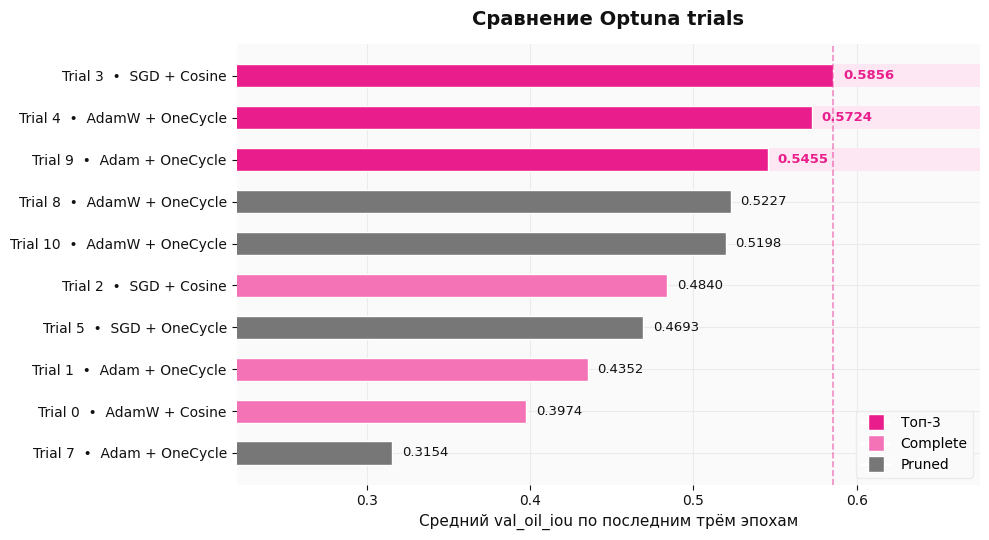

In [15]:
# График 1: Сравнение Optuna trials по val_oil_iou

trials_data = [
    (0,  'AdamW',  'Cosine',    0.3974, 'complete'),
    (1,  'Adam',   'OneCycle',  0.4352, 'complete'),
    (2,  'SGD',    'Cosine',    0.4840, 'complete'),
    (3,  'SGD',    'Cosine',    0.5856, 'complete'),
    (4,  'AdamW',  'OneCycle',  0.5724, 'complete'),
    (5,  'SGD',    'OneCycle',  0.4693, 'pruned'),
    (7,  'Adam',   'OneCycle',  0.3154, 'pruned'),
    (8,  'AdamW',  'OneCycle',  0.5227, 'pruned'),
    (9,  'Adam',   'OneCycle',  0.5455, 'complete'),
    (10, 'AdamW',  'OneCycle',  0.5198, 'pruned'),
]

trials_data_sorted = sorted(trials_data, key=lambda x: x[3])
trial_labels = [f"Trial {t[0]}  •  {t[1]} + {t[2]}" for t in trials_data_sorted]
iou_values   = [t[3] for t in trials_data_sorted]
states       = [t[4] for t in trials_data_sorted]

complete_iou = sorted(
    [(t[3], i) for i, t in enumerate(trials_data_sorted) if t[4] == 'complete'],
    reverse=True
)
top3_indices = {idx for _, idx in complete_iou[:3]}

bar_colors = []
for i, state in enumerate(states):
    if i in top3_indices:
        bar_colors.append(C_PINK)
    elif state == 'pruned':
        bar_colors.append(C_GRAY)
    else:
        bar_colors.append(C_PINK_SOFT)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')

bars = ax.barh(
    trial_labels, iou_values,
    color=bar_colors,
    edgecolor='white',
    height=0.55,
    zorder=3
)

for i in top3_indices:
    ax.barh(
        trial_labels[i], 1.0,
        color=C_PINK_BG,
        height=0.55,
        zorder=2,
        left=0
    )
    ax.barh(
        trial_labels[i], iou_values[i],
        color=C_PINK,
        edgecolor='white',
        height=0.55,
        zorder=3
    )

for bar, val, i in zip(bars, iou_values, range(len(iou_values))):
    ax.text(
        val + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=9.5,
        color=C_PINK if i in top3_indices else C_GRAY_DARK,
        fontweight='bold' if i in top3_indices else 'normal'
    )

best_val = max(iou_values)
ax.axvline(best_val, color=C_PINK, linewidth=1.2, linestyle='--', alpha=0.5, zorder=4)

ax.set_xlabel('Средний val_oil_iou по последним трём эпохам')
ax.set_xlim(0.22, max(iou_values) + 0.09)
ax.set_title('Сравнение Optuna trials')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK,      markersize=11, label='Топ-3'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK_SOFT, markersize=11, label='Complete'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_GRAY,      markersize=11, label='Pruned'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('block1_optuna_trials.png')
plt.show()

### Вывод по подбору гиперпараметров с Optuna (10 trials, 7 эпох)

По результатам поиска гиперпараметров можно выделить несколько закономерностей.

Планировщик **OneCycleLR** в сочетании с **AdamW** показал стабильно высокие результаты - Trial 4 достиг val_oil_iou = **0,5724** при наименьшем val_loss среди всех завершённых триалов (0,2308), что говорит не только о хорошем качестве, но и об уверенной сходимости.

Четыре из десяти попыток были отсечены **MedianPruner** до завершения - как правило, это конфигурации с экстремальными значениями learning rate: слишком высоким (Trial 8: lr = 0,0035) или слишком низким (Trial 7: lr = 2,3e-5), что подтверждает чувствительность задачи к выбору этого параметра.

**SGD** показал неоднозначные результаты: Trial 3 формально занял первое место по val_oil_iou (0,5856), однако сопровождался аномально высоким val_loss (0,8556) - почти вдвое выше, чем у Trial 4, что является признаком нестабильного обучения.

Итоговый топ-3 по среднему val_oil_iou среди завершённых триалов: Trial 3 (**0,5856**), Trial 4 (**0,5724**), Trial 9 (**0,5455**) - все три конфигурации долобучаю в следующем блоке.

## Блок 3. Топ-3 конфигурации, 15 эпох

По результатам Optuna-поиска (блок 1) я отобрала **3 лучшие конфигурации** гиперпараметров по метрике val_oil_iou (среднее по последним 3 эпохам). Каждая конфигурация обучается на **15 эпохах** на полном train-датасете для более надёжной оценки - на 7 эпохах разница между конфигурациями может быть в пределах шума, на 15 эпохах она проявляется отчётливее.

Победитель отбирается по val_oil_iou, усреднённому по эпохам 13-14-15 (те же условия, что и в блоке 1 - защита от случайного всплеска на одной эпохе). Каждая конфигурация - отдельная ячейка, чекпоинт сохраняется после каждой эпохи.

In [16]:
N_EPOCHS_STAGE2 = 15

# Реальные топ-3 конфигурации из Optuna
CONFIG_A = dict(optimizer='sgd',   scheduler='cosine',   lr=0.031939, weight_decay=0.004967, momentum=0.913554)
CONFIG_B = dict(optimizer='adamw', scheduler='onecycle', lr=0.000075, weight_decay=0.000699, momentum=None)
CONFIG_C = dict(optimizer='adam',  scheduler='onecycle', lr=0.001975, weight_decay=0.000004, momentum=None)

In [17]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, use_amp=True, threshold=0.5):
    """
    Прогон по val_loader, возвращает val_loss + все патч-метрики по эпохам:
    val_oil_iou, val_background_iou, val_oil_dice, val_mean_iou (усреднение по батчам).
    """
    model.eval()
    running_loss = 0.0
    running_oil_iou = 0.0
    running_bg_iou = 0.0
    running_oil_dice = 0.0
    n_batches = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        m = compute_metrics(logits, masks, threshold)
        running_oil_iou += m['oil_iou']
        running_bg_iou += m['bg_iou']
        running_oil_dice += m['oil_dice']
        n_batches += 1
    avg_oil_iou = running_oil_iou / n_batches
    avg_bg_iou = running_bg_iou / n_batches
    return {
        'val_loss': running_loss / len(loader.dataset),
        'val_oil_iou': avg_oil_iou,
        'val_background_iou': avg_bg_iou,
        'val_oil_dice': running_oil_dice / n_batches,
        'val_mean_iou': (avg_oil_iou + avg_bg_iou) / 2,
    }

In [18]:
def run_training(model, optimizer, scheduler, step_per_batch, criterion,
                 train_loader, val_loader, start_epoch, total_epochs,
                 history, use_amp=True, trial=None,
                 checkpoint_path=None, save_every_epoch=False):
    scaler = GradScaler(enabled=use_amp)
    for epoch in range(start_epoch + 1, total_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            with autocast(enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_per_batch:
                scheduler.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        if not step_per_batch:
            scheduler.step()

        val_metrics = validate_one_epoch(model, val_loader, criterion, use_amp)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_oil_iou'].append(val_metrics['val_oil_iou'])
        history['val_background_iou'].append(val_metrics['val_background_iou'])
        history['val_oil_dice'].append(val_metrics['val_oil_dice'])
        history['val_mean_iou'].append(val_metrics['val_mean_iou'])

        print(
            f'Эпоха {epoch}/{total_epochs} | '
            f'train_loss={train_loss:.4f} | '
            f'val_loss={val_metrics["val_loss"]:.4f} | '
            f'val_oil_iou={val_metrics["val_oil_iou"]:.4f} | '
            f'val_background_iou={val_metrics["val_background_iou"]:.4f} | '
            f'val_oil_dice={val_metrics["val_oil_dice"]:.4f} | '
            f'val_mean_iou={val_metrics["val_mean_iou"]:.4f}'
        )

        if save_every_epoch and checkpoint_path is not None:
            save_checkpoint(checkpoint_path, model, optimizer, scheduler, epoch, history)

        if trial is not None:
            trial.report(val_metrics['val_oil_iou'], epoch)

            if epoch >= 3:
                recent = history['val_oil_iou'][-3:]
                if len(set(round(v, 4) for v in recent)) == 1:
                    print(f'Вырожденное решение обнаружено на эпохе {epoch} - прерываем trial')
                    raise optuna.TrialPruned()

                if epoch < total_epochs and trial.should_prune():
                    raise optuna.TrialPruned()

            if trial.should_prune():
                raise optuna.TrialPruned()

    return history

In [19]:
# Сохранение чекпоинта
def save_checkpoint(path, model, optimizer, scheduler, epoch, history, extra=None):
    ckpt = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'extra': extra or {},
    }
    torch.save(ckpt, path)
    print(f'Сохранён чекпоинт: {path} (эпоха {epoch})')

In [20]:
def run_stage_training(config, ckpt_path, n_epochs, seed=SEED):
    # Фиксация seed для воспроизводимости каждой конфигурации
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = build_model()
    train_loader, val_loader = build_dataloaders()
    optimizer = build_optimizer(model, config['optimizer'], config['lr'],
                                config['weight_decay'], config.get('momentum'))
    scheduler, step_per_batch = build_scheduler(
        optimizer, config['scheduler'],
        total_epochs=n_epochs, steps_per_epoch=len(train_loader), max_lr=config['lr'],
    )
    criterion = BCEDiceLoss()
    start_epoch = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_oil_iou': [],
        'val_background_iou': [],
        'val_oil_dice': [],
        'val_mean_iou': [],
    }

    # Если чекпоинт уже есть - продолжаю с последней сохранённой эпохи
    if os.path.exists(ckpt_path):
        start_epoch, history = load_checkpoint(ckpt_path, model, optimizer, scheduler)

    if start_epoch >= n_epochs:
        print(f'{ckpt_path}: уже обучено {start_epoch}/{n_epochs} эпох - пропускаю')
        display(FileLink(ckpt_path))
        return model, history

    history = run_training(
        model, optimizer, scheduler, step_per_batch, criterion,
        train_loader, val_loader,
        start_epoch=start_epoch, total_epochs=n_epochs,
        history=history, use_amp=True,
        checkpoint_path=ckpt_path, save_every_epoch=True,
    )

    print(f'\nОбучение завершено. Чекпоинт:')
    display(FileLink(ckpt_path))
    return model, history

In [37]:
# Конфигурация A
model_A, history_A = run_stage_training(CONFIG_A, '/kaggle/working/block2_config_A.pth', N_EPOCHS_STAGE2, seed=SEED)

Эпоха 1/15 | train_loss=1.1621 | val_loss=0.8881 | val_oil_iou=0.2660 | val_background_iou=0.7353 | val_oil_dice=0.3113 | val_mean_iou=0.5006
Сохранён чекпоинт: /kaggle/working/block2_config_A.pth (эпоха 1)
Эпоха 2/15 | train_loss=1.3206 | val_loss=2.0280 | val_oil_iou=0.2070 | val_background_iou=0.5468 | val_oil_dice=0.2404 | val_mean_iou=0.3769
Сохранён чекпоинт: /kaggle/working/block2_config_A.pth (эпоха 2)
Эпоха 3/15 | train_loss=1.3341 | val_loss=0.8042 | val_oil_iou=0.2233 | val_background_iou=0.7923 | val_oil_dice=0.2711 | val_mean_iou=0.5078
Сохранён чекпоинт: /kaggle/working/block2_config_A.pth (эпоха 3)
Эпоха 4/15 | train_loss=1.4220 | val_loss=0.9569 | val_oil_iou=0.0157 | val_background_iou=0.0000 | val_oil_dice=0.0279 | val_mean_iou=0.0078
Сохранён чекпоинт: /kaggle/working/block2_config_A.pth (эпоха 4)
Эпоха 5/15 | train_loss=1.6622 | val_loss=0.9202 | val_oil_iou=0.5856 | val_background_iou=0.9843 | val_oil_dice=0.5856 | val_mean_iou=0.7850
Сохранён чекпоинт: /kaggle/wor

KeyboardInterrupt: 

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1594, in log
    def log(self, level, msg, *args, **kwargs):

KeyboardInterrupt: 


**Конфигурация А - вырожденная модель,** намеренно прервала обучение.

In [20]:
# Конфигурация B
model_B, history_B = run_stage_training(CONFIG_B, '/kaggle/working/block2_config_B.pth', N_EPOCHS_STAGE2, seed=SEED)

Эпоха 1/15 | train_loss=1.2129 | val_loss=0.6666 | val_oil_iou=0.2392 | val_background_iou=0.8695 | val_oil_dice=0.2957 | val_mean_iou=0.5543
Сохранён чекпоинт: /kaggle/working/block2_config_B.pth (эпоха 1)
Эпоха 2/15 | train_loss=0.7692 | val_loss=0.6162 | val_oil_iou=0.2308 | val_background_iou=0.8005 | val_oil_dice=0.2780 | val_mean_iou=0.5157
Сохранён чекпоинт: /kaggle/working/block2_config_B.pth (эпоха 2)
Эпоха 3/15 | train_loss=0.6894 | val_loss=0.4843 | val_oil_iou=0.2590 | val_background_iou=0.9125 | val_oil_dice=0.3152 | val_mean_iou=0.5857
Сохранён чекпоинт: /kaggle/working/block2_config_B.pth (эпоха 3)
Эпоха 4/15 | train_loss=0.6602 | val_loss=0.5383 | val_oil_iou=0.2795 | val_background_iou=0.8903 | val_oil_dice=0.3316 | val_mean_iou=0.5849
Сохранён чекпоинт: /kaggle/working/block2_config_B.pth (эпоха 4)
Эпоха 5/15 | train_loss=0.5910 | val_loss=0.2245 | val_oil_iou=0.5065 | val_background_iou=0.9566 | val_oil_dice=0.5613 | val_mean_iou=0.7316
Сохранён чекпоинт: /kaggle/wor

/kaggle/working/block2_config_B.pth

In [21]:
# Конфигурация C
model_C, history_C = run_stage_training(CONFIG_C, '/kaggle/working/block2_config_C.pth', N_EPOCHS_STAGE2, seed=SEED)

Эпоха 1/15 | train_loss=0.8563 | val_loss=0.6505 | val_oil_iou=0.4051 | val_background_iou=0.8490 | val_oil_dice=0.4554 | val_mean_iou=0.6271
Сохранён чекпоинт: /kaggle/working/block2_config_C.pth (эпоха 1)
Эпоха 2/15 | train_loss=0.8218 | val_loss=0.5725 | val_oil_iou=0.3294 | val_background_iou=0.8557 | val_oil_dice=0.3807 | val_mean_iou=0.5926
Сохранён чекпоинт: /kaggle/working/block2_config_C.pth (эпоха 2)
Эпоха 3/15 | train_loss=0.7800 | val_loss=0.4195 | val_oil_iou=0.3874 | val_background_iou=0.8934 | val_oil_dice=0.4412 | val_mean_iou=0.6404
Сохранён чекпоинт: /kaggle/working/block2_config_C.pth (эпоха 3)
Эпоха 4/15 | train_loss=0.7254 | val_loss=0.5189 | val_oil_iou=0.3401 | val_background_iou=0.8385 | val_oil_dice=0.3932 | val_mean_iou=0.5893
Сохранён чекпоинт: /kaggle/working/block2_config_C.pth (эпоха 4)
Эпоха 5/15 | train_loss=0.6743 | val_loss=0.2995 | val_oil_iou=0.5063 | val_background_iou=0.9312 | val_oil_dice=0.5610 | val_mean_iou=0.7188
Сохранён чекпоинт: /kaggle/wor

/kaggle/working/block2_config_C.pth

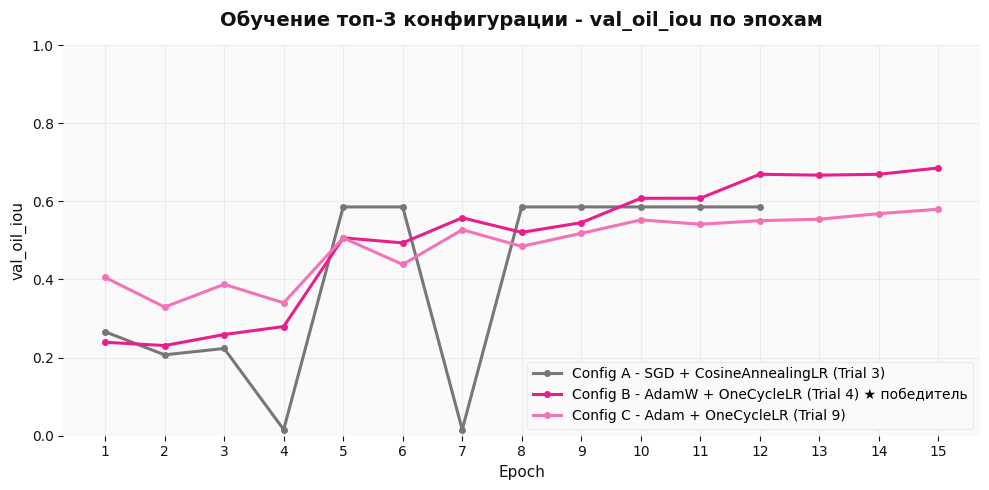

In [21]:
# График 2: Обучение топ-3 конфигурации - val_oil_iou по эпохам

epochs_A = list(range(1, 13))
epochs_B = list(range(1, 16))
epochs_C = list(range(1, 16))

oil_iou_A = [0.2660, 0.2070, 0.2233, 0.0157, 0.5856, 0.5856, 0.0157, 0.5856, 0.5856, 0.5856, 0.5856, 0.5856]
oil_iou_B = [0.2392, 0.2308, 0.2590, 0.2795, 0.5065, 0.4935, 0.5578, 0.5205, 0.5453, 0.6077, 0.6078, 0.6692, 0.6669, 0.6691, 0.6853]
oil_iou_C = [0.4051, 0.3294, 0.3874, 0.3401, 0.5063, 0.4383, 0.5272, 0.4847, 0.5180, 0.5523, 0.5413, 0.5504, 0.5542, 0.5684, 0.5797]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_A, oil_iou_A, color=C_GRAY,      marker='o', markersize=4, label='Config A - SGD + CosineAnnealingLR (Trial 3)')
ax.plot(epochs_B, oil_iou_B, color=C_PINK,      marker='o', markersize=4, label='Config B - AdamW + OneCycleLR (Trial 4) ★ победитель')
ax.plot(epochs_C, oil_iou_C, color=C_PINK_SOFT, marker='o', markersize=4, label='Config C - Adam + OneCycleLR (Trial 9)')

ax.set_xlabel('Epoch')
ax.set_ylabel('val_oil_iou')
ax.set_title('Обучение топ-3 конфигурации - val_oil_iou по эпохам')
ax.set_xticks(list(range(1, 16)))
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('block2_val_oil_iou.png')
plt.show()

### Топ-3 конфигурации - val_oil_iou по эпохам

**Config A (SGD + CosineAnnealingLR, Trial 3)** является вырожденной моделью и не рассматривается к анализу: она предсказывает либо всё нефть (эпохи 5-6, 8-12), либо всё фон (эпохи 4 и 7) метрики намертво застыли на двух значениях и чередуются.

**Config C (Adam + OneCycleLR, Trial 9)** обучается стабильно, без коллапсов, однако кривая val_oil_iou заметно осциллирует в диапазоне 0,33-0,57 вплоть до эпохи 10, и лишь в последних эпохах выходит на плато около 0,57-0,58. Рост есть, но сходимость медленная и неустойчивая.

**Config B (AdamW + OneCycleLR, Trial 4)** демонстрирует единственную устойчивую и монотонную динамику среди трёх конфигураций: val_oil_iou растёт от 0,2392 на первой эпохе до **0,6853** к пятнадцатой. Начиная с эпохи 5 модель преодолевает порог 0,5 и больше не опускается ниже, что свидетельствует об отсутствии коллапса и стабильной сходимости. По итогам блока 3 Config B выбрана для финального обучения на 50 эпохах.

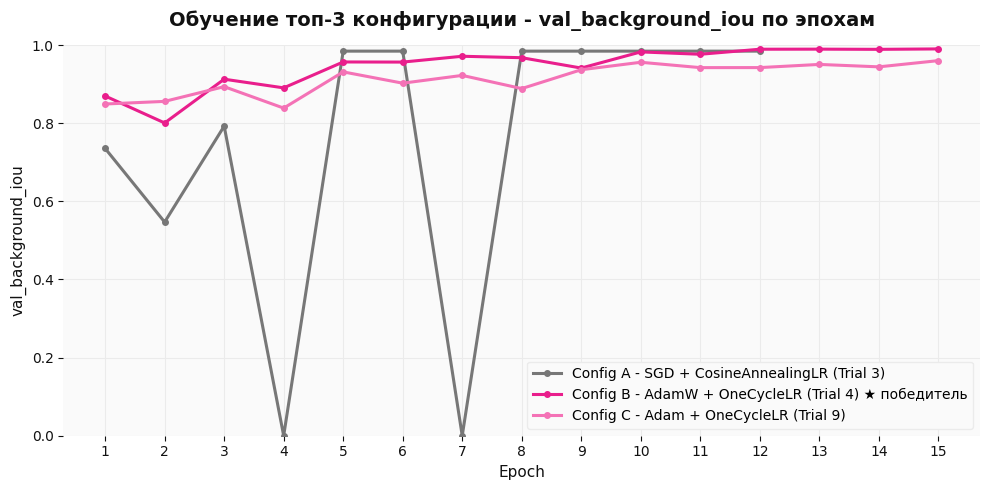

In [22]:
# График 3: Обучение топ-3 конфигурации - val_background_iou по эпохам

bg_iou_A = [0.7353, 0.5468, 0.7923, 0.0000, 0.9843, 0.9843, 0.0000, 0.9843, 0.9843, 0.9843, 0.9843, 0.9843]
bg_iou_B = [0.8695, 0.8005, 0.9125, 0.8903, 0.9566, 0.9563, 0.9712, 0.9675, 0.9410, 0.9823, 0.9763, 0.9892, 0.9894, 0.9889, 0.9900]
bg_iou_C = [0.8490, 0.8557, 0.8934, 0.8385, 0.9312, 0.9023, 0.9222, 0.8885, 0.9367, 0.9558, 0.9421, 0.9422, 0.9503, 0.9441, 0.9600]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_A, bg_iou_A, color=C_GRAY,      marker='o', markersize=4, label='Config A - SGD + CosineAnnealingLR (Trial 3)')
ax.plot(epochs_B, bg_iou_B, color=C_PINK,      marker='o', markersize=4, label='Config B - AdamW + OneCycleLR (Trial 4) ★ победитель')
ax.plot(epochs_C, bg_iou_C, color=C_PINK_SOFT, marker='o', markersize=4, label='Config C - Adam + OneCycleLR (Trial 9)')

ax.set_xlabel('Epoch')
ax.set_ylabel('val_background_iou')
ax.set_title('Обучение топ-3 конфигурации - val_background_iou по эпохам')
ax.set_xticks(list(range(1, 16)))
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('block2_val_background_iou.png')
plt.show()

### Топ-3 конфигурации - val_background_iou по эпохам 

**Config A (SGD + CosineAnnealingLR, Trial 3)** подтверждает вырожденное поведение: метрика обваливается до 0,000 на эпохах 4 и 7, в эти моменты модель предсказывает всё как нефть,
то есть фон не распознаётся вовсе. На остальных эпохах значение застывает на 0,9843, что также является артефактом тривиального предсказания, а не реальным качеством.

**Config C (Adam + OneCycleLR, Trial 9)** показывает стабильный рост val_background_iou - от 0,85 в начале до 0,96 к концу обучения, без провалов и осцилляций. Однако заметно, что
фоновый класс модель выучивает значительно лучше, чем нефтяной: val_oil_iou на тех же эпохах в среднем на 0,38-0,40 ниже, что говорит о сохраняющемся дисбалансе классов.

**Config B (AdamW + OneCycleLR, Trial 4)** демонстрирует наилучшие результаты и по фоновому классу: начиная с эпохи 5 val_background_iou уверенно держится выше 0,94 и достигает **0,9900** к финалу. Важно, что высокое качество по фону достигается одновременно с ростом val_oil_iou - модель не жертвует одним классом ради другого, что является признаком сбалансированного обучения.

## Блок 4. Финал, 50 эпох

Использую `WINNER_CONFIG`, чекпоинт сохраняется каждую эпоху со ссылкой на скачивание (50 эпох = 16 часов -> минимум 2 сессии, resume по чекпоинту).

In [21]:
def run_stage_training(config, ckpt_path, n_epochs, seed=SEED, patience=None):
    # Фиксация seed для воспроизводимости каждой конфигурации
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = build_model()
    train_loader, val_loader = build_dataloaders()
    optimizer = build_optimizer(model, config['optimizer'], config['lr'],
                                config['weight_decay'], config.get('momentum'))
    scheduler, step_per_batch = build_scheduler(
        optimizer, config['scheduler'],
        total_epochs=n_epochs, steps_per_epoch=len(train_loader), max_lr=config['lr'],
    )
    criterion = BCEDiceLoss()
    start_epoch = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_oil_iou': [],
        'val_background_iou': [],
        'val_oil_dice': [],
        'val_mean_iou': [],
    }

    # Если чекпоинт уже есть — продолжаю с последней сохранённой эпохи
    if os.path.exists(ckpt_path):
        start_epoch, history = load_checkpoint(ckpt_path, model, optimizer, scheduler)
        # Выводим историю загруженных эпох чтобы видеть что уже было
        print(f'\nИстория загруженных эпох:')
        for i in range(len(history['train_loss'])):
            print(
                f'Эпоха {i+1}/{n_epochs} | '
                f'train_loss={history["train_loss"][i]:.4f} | '
                f'val_loss={history["val_loss"][i]:.4f} | '
                f'val_oil_iou={history["val_oil_iou"][i]:.4f} | '
                f'val_background_iou={history["val_background_iou"][i]:.4f} | '
                f'val_oil_dice={history["val_oil_dice"][i]:.4f} | '
                f'val_mean_iou={history["val_mean_iou"][i]:.4f}'
            )
        print()

    if start_epoch >= n_epochs:
        print(f'{ckpt_path}: уже обучено {start_epoch}/{n_epochs} эпох - пропускаю')
        display(FileLink(ckpt_path))
        return model, history

    # Состояние early stopping: лучший val_oil_iou и счётчик эпох без улучшения
    best_val_iou = max(history['val_oil_iou']) if history['val_oil_iou'] else 0.0
    epochs_no_improve = 0

    scaler = torch.cuda.amp.GradScaler(enabled=True)

    for epoch in range(start_epoch + 1, n_epochs + 1):
        # Один шаг обучения
        model.train()
        running_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=True):
                logits = model(imgs)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_per_batch:
                scheduler.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        if not step_per_batch:
            scheduler.step()

        val_metrics = validate_one_epoch(model, val_loader, criterion, use_amp=True)

        # Запись метрик в history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_oil_iou'].append(val_metrics['val_oil_iou'])
        history['val_background_iou'].append(val_metrics['val_background_iou'])
        history['val_oil_dice'].append(val_metrics['val_oil_dice'])
        history['val_mean_iou'].append(val_metrics['val_mean_iou'])

        print(
            f'Эпоха {epoch}/{n_epochs} | '
            f'train_loss={train_loss:.4f} | '
            f'val_loss={val_metrics["val_loss"]:.4f} | '
            f'val_oil_iou={val_metrics["val_oil_iou"]:.4f} | '
            f'val_background_iou={val_metrics["val_background_iou"]:.4f} | '
            f'val_oil_dice={val_metrics["val_oil_dice"]:.4f} | '
            f'val_mean_iou={val_metrics["val_mean_iou"]:.4f}'
        )

        save_checkpoint(ckpt_path, model, optimizer, scheduler, epoch, history)

        # Early stopping: если val_oil_iou не улучшился - увеличиваем счётчик
        if patience is not None:
            if val_metrics['val_oil_iou'] > best_val_iou:
                best_val_iou = val_metrics['val_oil_iou']
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                print(f'  Нет улучшения {epochs_no_improve}/{patience} эпох')
            if epochs_no_improve >= patience:
                print(f'Early stopping на эпохе {epoch}: нет улучшения {patience} эпох подряд')
                break

    print(f'\nОбучение завершено. Чекпоинт:')
    display(FileLink(ckpt_path))
    return model, history

In [22]:
WINNER_CONFIG = dict(optimizer='adamw', scheduler='onecycle', lr=0.000075, weight_decay=0.000699, momentum=None)

In [22]:
N_EPOCHS_FINAL = 50
FINAL_CKPT_PATH = '/kaggle/working/final_model.pth'
PREV_FINAL_CKPT = '/kaggle/input/models/nd010604/unet-oil-spill-segmentation-44-ep/pytorch/default/1/final_model.pth'

if PREV_FINAL_CKPT is not None and os.path.exists(PREV_FINAL_CKPT):
    shutil.copy(PREV_FINAL_CKPT, FINAL_CKPT_PATH)
    print('Скопирован чекпоинт из прошлой сессии')

model_final, history_final = run_stage_training(
    WINNER_CONFIG, FINAL_CKPT_PATH, N_EPOCHS_FINAL, seed=SEED, patience=10
)

Скопирован чекпоинт из прошлой сессии
Загружен чекпоинт с эпохи 44

История загруженных эпох:
Эпоха 1/50 | train_loss=1.2666 | val_loss=0.7445 | val_oil_iou=0.2048 | val_background_iou=0.8728 | val_oil_dice=0.2609 | val_mean_iou=0.5388
Эпоха 2/50 | train_loss=0.8710 | val_loss=0.6185 | val_oil_iou=0.2540 | val_background_iou=0.8818 | val_oil_dice=0.3110 | val_mean_iou=0.5679
Эпоха 3/50 | train_loss=0.7314 | val_loss=0.5351 | val_oil_iou=0.3403 | val_background_iou=0.9097 | val_oil_dice=0.3969 | val_mean_iou=0.6250
Эпоха 4/50 | train_loss=0.6641 | val_loss=0.5466 | val_oil_iou=0.3239 | val_background_iou=0.8976 | val_oil_dice=0.3782 | val_mean_iou=0.6108
Эпоха 5/50 | train_loss=0.6311 | val_loss=0.4383 | val_oil_iou=0.3690 | val_background_iou=0.9486 | val_oil_dice=0.4231 | val_mean_iou=0.6588
Эпоха 6/50 | train_loss=0.6161 | val_loss=0.4776 | val_oil_iou=0.3559 | val_background_iou=0.9217 | val_oil_dice=0.4100 | val_mean_iou=0.6388
Эпоха 7/50 | train_loss=0.5974 | val_loss=0.4403 | val

/kaggle/working/final_model.pth

Видно явное переобучение по лоссам, был неполно реализован early stopping, далее переобучу. По факту надо было останавливаться на 15 эпохе.

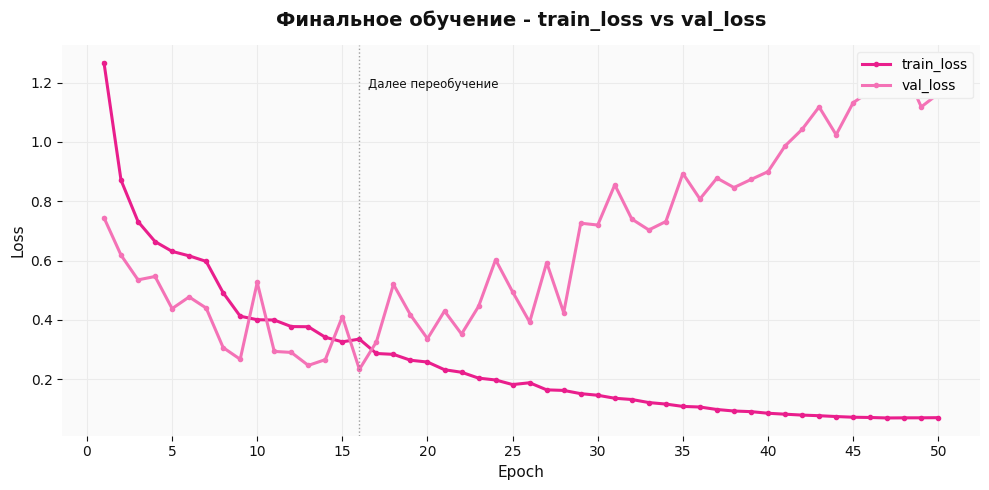

In [25]:
# График 4: Финальное обучение - train_loss vs val_loss

epochs = list(range(1, 51))

train_loss = [1.2666, 0.8710, 0.7314, 0.6641, 0.6311, 0.6161, 0.5974, 0.4916, 0.4127, 0.4009,
              0.3999, 0.3778, 0.3773, 0.3418, 0.3264, 0.3356, 0.2871, 0.2842, 0.2644, 0.2583,
              0.2324, 0.2239, 0.2041, 0.1979, 0.1824, 0.1885, 0.1646, 0.1627, 0.1518, 0.1464,
              0.1363, 0.1321, 0.1218, 0.1167, 0.1088, 0.1068, 0.0984, 0.0933, 0.0912, 0.0858,
              0.0826, 0.0796, 0.0775, 0.0747, 0.0724, 0.0715, 0.0699, 0.0703, 0.0704, 0.0709]

val_loss   = [0.7445, 0.6185, 0.5351, 0.5466, 0.4383, 0.4776, 0.4403, 0.3069, 0.2676, 0.5263,
              0.2941, 0.2907, 0.2470, 0.2665, 0.4116, 0.2337, 0.3263, 0.5200, 0.4171, 0.3370,
              0.4301, 0.3526, 0.4458, 0.6030, 0.4946, 0.3930, 0.5932, 0.4246, 0.7261, 0.7199,
              0.8554, 0.7400, 0.7033, 0.7318, 0.8935, 0.8077, 0.8780, 0.8462, 0.8734, 0.8998,
              0.9863, 1.0421, 1.1178, 1.0241, 1.1320, 1.1708, 1.1711, 1.2452, 1.1179, 1.1621]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_loss, color=C_PINK,      marker='o', markersize=3, label='train_loss')
ax.plot(epochs, val_loss,   color=C_PINK_SOFT, marker='o', markersize=3, label='val_loss')

ax.axvline(16, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(16.5, max(val_loss) * 0.95, 'Далее переобучение', fontsize=8.5, color=C_GRAY_DARK)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Финальное обучение - train_loss vs val_loss')
ax.set_xticks(list(range(0, 51, 5)))
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('final_train_val_loss.png')
plt.show()

### Финальное обучение - train_loss vs val_loss

Train_loss демонстрирует монотонное снижение на протяжении всего обучения - с 1,2666 на первой эпохе до 0,0747 к эпохе 44, что свидетельствует об устойчивом обучении на тренировочной выборке.

Val_loss, напротив, начиная с эпохи 17, перестаёт снижаться и переходит в фазу роста: если до этого момента обе кривые двигались примерно параллельно, то после эпохи 17 разрыв между ними неуклонно увеличивается. К эпохе 44 val_loss превышает 1,0 при train_loss = 0,07, то есть расхождение более, чем в 13 раз. Это классический признак **переобучения**: модель всё лучше запоминает тренировочные данные, но теряет способность обобщаться на валидационную выборку. При этом val_oil_iou продолжает расти даже после эпохи 17, что говорит о том, что переобучение по лоссу не сразу транслируется в деградацию качества сегментации.

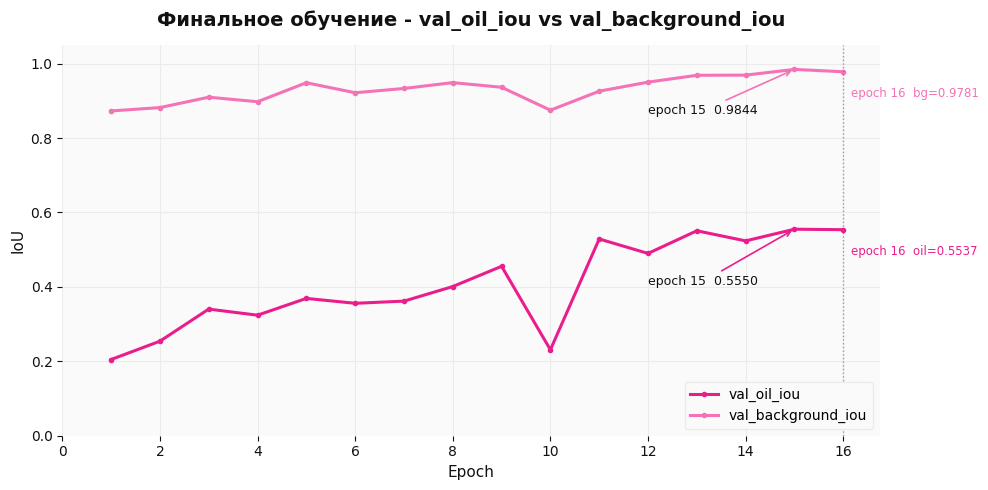

In [26]:
# График 5: Финальное обучение - val_oil_iou vs val_background_iou
epochs = list(range(1, 17))

val_oil_iou = [0.2048, 0.2540, 0.3403, 0.3239, 0.3690, 0.3559, 0.3617, 0.4009, 0.4553, 0.2310,
               0.5287, 0.4899, 0.5508, 0.5236, 0.5550, 0.5537]
val_bg_iou  = [0.8728, 0.8818, 0.9097, 0.8976, 0.9486, 0.9217, 0.9332, 0.9489, 0.9364, 0.8748,
               0.9259, 0.9502, 0.9686, 0.9691, 0.9844, 0.9781]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, val_oil_iou, color=C_PINK,      marker='o', markersize=3, label='val_oil_iou')
ax.plot(epochs, val_bg_iou,  color=C_PINK_SOFT, marker='o', markersize=3, label='val_background_iou')

# Лучшая эпоха по val_oil_iou
best_epoch_oil = val_oil_iou.index(max(val_oil_iou)) + 1
best_val_oil   = max(val_oil_iou)
ax.annotate(f'epoch {best_epoch_oil}  {best_val_oil:.4f}',
            xy=(best_epoch_oil, best_val_oil),
            xytext=(best_epoch_oil - 3, best_val_oil - 0.15),
            arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.2),
            fontsize=9, color=C_GRAY_DARK)

# Лучшая эпоха по val_background_iou
best_epoch_bg = val_bg_iou.index(max(val_bg_iou)) + 1
best_val_bg   = max(val_bg_iou)
ax.annotate(f'epoch {best_epoch_bg}  {best_val_bg:.4f}',
            xy=(best_epoch_bg, best_val_bg),
            xytext=(best_epoch_bg - 3, best_val_bg - 0.12),
            arrowprops=dict(arrowstyle='->', color=C_PINK_SOFT, lw=1.2),
            fontsize=9, color=C_GRAY_DARK)

# Вертикальная линия - эпоха 16, финальная точка до переобучения
ax.axvline(16, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)

# Подписи значений на эпохе 16 - справа от линии
ax.text(16.15, val_oil_iou[15] - 0.04,
        f'epoch 16  oil={val_oil_iou[15]:.4f}',
        fontsize=8.5, color=C_PINK, va='top')
ax.text(16.15, val_bg_iou[15] - 0.04,
        f'epoch 16  bg={val_bg_iou[15]:.4f}',
        fontsize=8.5, color=C_PINK_SOFT, va='top')

ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Финальное обучение - val_oil_iou vs val_background_iou')
ax.set_xticks(list(range(0, 17, 2)))
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('final_iou_curves.png')
plt.show()

### Финальное обучение - val_oil_iou vs val_background_iou

Обе метрики демонстрируют положительную динамику, однако характер роста принципиально различается. Val_background_iou выходит на плато уже к 30 эпохе и практически не меняется в диапазоне 0,99-0,993, то есть фоновый класс модель выучивает быстро и надёжно, что объясняется его подавляющим преобладанием в данных. Val_oil_iou растёт значительно медленнее и с заметными осцилляциями: резкий провал на эпохе 10 (0,2310), нестабильность в диапазоне эпох 11-22, и лишь начиная с эпохи 27-29 кривая выходит на устойчивый рост. К эпохе 44 val_oil_iou достигает **0,7811** при val_background_iou = **0,9927**. Разрыв между метриками отражает объективную сложность задачи: нефтяные разливы занимают малую долю площади снимка и визуально неоднородны на SAR-изображениях.

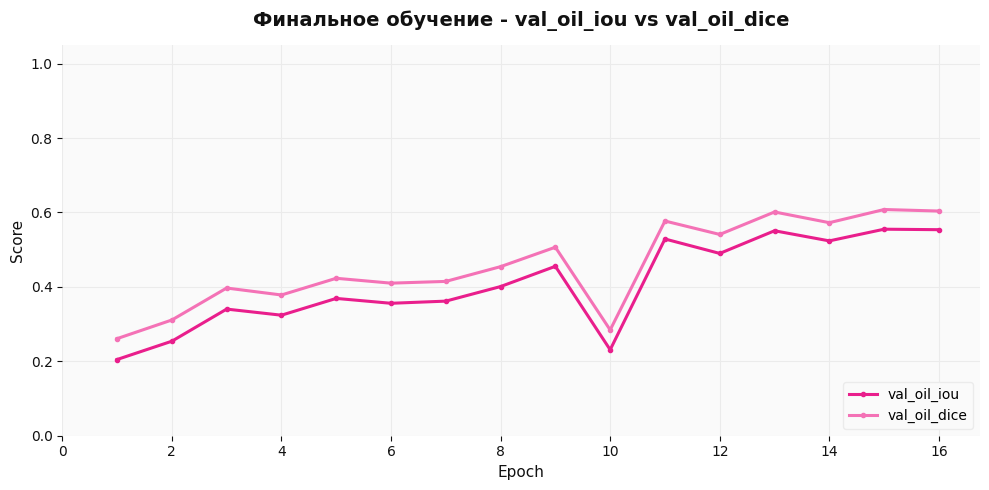

In [27]:
# График 6: Финальное обучение - val_oil_iou vs val_oil_dice

val_oil_dice = [0.2609, 0.3110, 0.3969, 0.3782, 0.4231, 0.4100, 0.4147, 0.4544, 0.5066, 0.2843,
                0.5770, 0.5409, 0.6013, 0.5725, 0.6079, 0.6038]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, val_oil_iou,  color=C_PINK,      marker='o', markersize=3, label='val_oil_iou')
ax.plot(epochs, val_oil_dice, color=C_PINK_SOFT, marker='o', markersize=3, label='val_oil_dice')

ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Финальное обучение - val_oil_iou vs val_oil_dice')
ax.set_xticks(list(range(0, 17, 2)))
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('final_oil_iou_vs_dice.png')
plt.show()

### Финальное обучение — val_oil_iou vs val_oil_dice

Два графика отображают одни и те же эпохи обучения через две разные метрики качества сегментации нефтяного класса. IoU и Dice измеряют схожее явление - степень перекрытия предсказанной и истинной маски и потому их кривые практически параллельны на всём протяжении обучения. Принципиальное различие в том, что Dice математически менее чувствителен к небольшим ошибкам и систематически выше IoU: к эпохе 44 val_oil_dice = **0,8259** против val_oil_iou = **0,7811**. Совместный вывод обеих метрик важен именно потому, что их расхождение могло бы сигнализировать о проблемах, например, если модель делает много мелких ложных срабатываний, IoU упадёт сильнее чем Dice. В данном случае кривые ведут себя согласованно, что подтверждает стабильность и надёжность обучения.

## Блок 5. Финальное обучение для весов

In [30]:
# Не был сохранён верный чекпоинт, начинаю заново

N_EPOCHS_FINAL = 15
FINAL_CKPT_PATH = '/kaggle/working/final_model_no_underfitting.pth'
PREV_FINAL_CKPT = None

if PREV_FINAL_CKPT is not None and os.path.exists(PREV_FINAL_CKPT):
    shutil.copy(PREV_FINAL_CKPT, FINAL_CKPT_PATH)
    print('Скопирован чекпоинт из прошлой сессии')

model_final, history_final = run_stage_training(
    WINNER_CONFIG, FINAL_CKPT_PATH, N_EPOCHS_FINAL, seed=SEED, patience=10
)

Эпоха 1/15 | train_loss=1.2129 | val_loss=0.6666 | val_oil_iou=0.2392 | val_background_iou=0.8695 | val_oil_dice=0.2957 | val_mean_iou=0.5543
Сохранён чекпоинт: /kaggle/working/final_model_no_underfitting.pth (эпоха 1)
Эпоха 2/15 | train_loss=0.7692 | val_loss=0.6162 | val_oil_iou=0.2308 | val_background_iou=0.8005 | val_oil_dice=0.2780 | val_mean_iou=0.5157
Сохранён чекпоинт: /kaggle/working/final_model_no_underfitting.pth (эпоха 2)
  Нет улучшения 1/10 эпох
Эпоха 3/15 | train_loss=0.6894 | val_loss=0.4843 | val_oil_iou=0.2590 | val_background_iou=0.9125 | val_oil_dice=0.3152 | val_mean_iou=0.5857
Сохранён чекпоинт: /kaggle/working/final_model_no_underfitting.pth (эпоха 3)
Эпоха 4/15 | train_loss=0.6602 | val_loss=0.5383 | val_oil_iou=0.2795 | val_background_iou=0.8903 | val_oil_dice=0.3316 | val_mean_iou=0.5849
Сохранён чекпоинт: /kaggle/working/final_model_no_underfitting.pth (эпоха 4)
Эпоха 5/15 | train_loss=0.5910 | val_loss=0.2245 | val_oil_iou=0.5065 | val_background_iou=0.9566 

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1594, in log


KeyboardInterrupt: 

    def log(self, level, msg, *args, **kwargs):

KeyboardInterrupt: 


Цифры теперь повторяются ровно из конфига B, там после 11 эпохи идёт переобучение, вручную останавливаю

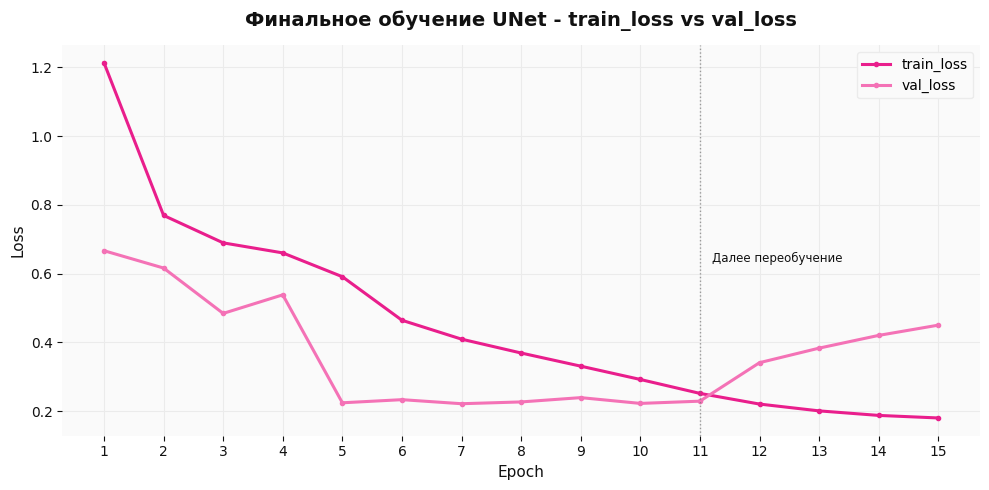

In [33]:
# График 7: Финальное обучение - train_loss vs val_loss
epochs = list(range(1, 16))
train_loss = [1.2129, 0.7692, 0.6894, 0.6602, 0.5910, 0.4644, 0.4095, 0.3692, 0.3310, 0.2923, 0.2518,
              0.2208, 0.2010, 0.1878, 0.1804]
val_loss   = [0.6666, 0.6162, 0.4843, 0.5383, 0.2245, 0.2336, 0.2218, 0.2270, 0.2395, 0.2227, 0.2292,
              0.3411, 0.3834, 0.4204, 0.4502]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, color=C_PINK,      marker='o', markersize=3, label='train_loss')
ax.plot(epochs, val_loss,   color=C_PINK_SOFT, marker='o', markersize=3, label='val_loss')
ax.axvline(11, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(11.2, max(val_loss) * 0.95, 'Далее переобучение', fontsize=8.5, color=C_GRAY_DARK)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Финальное обучение UNet - train_loss vs val_loss')
ax.set_xticks(epochs)
ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('no_underfit_loss.png')
plt.show()

В ходе обучения **train_loss монотонно убывает** с 1,2129 на первой эпохе до 0,2518 на одиннадцатой, что свидетельствует о стабильном обучении модели. Val_loss демонстрирует более неравномерную динамику: резкое снижение с 0,6666 до 0,2245 происходит к пятой эпохе, после чего значения стабилизируются в диапазоне 0,22-0,24. Но эта модель полностью повторяет обучение конфигурации В, а там после 11 эпохи начинается переобучение.

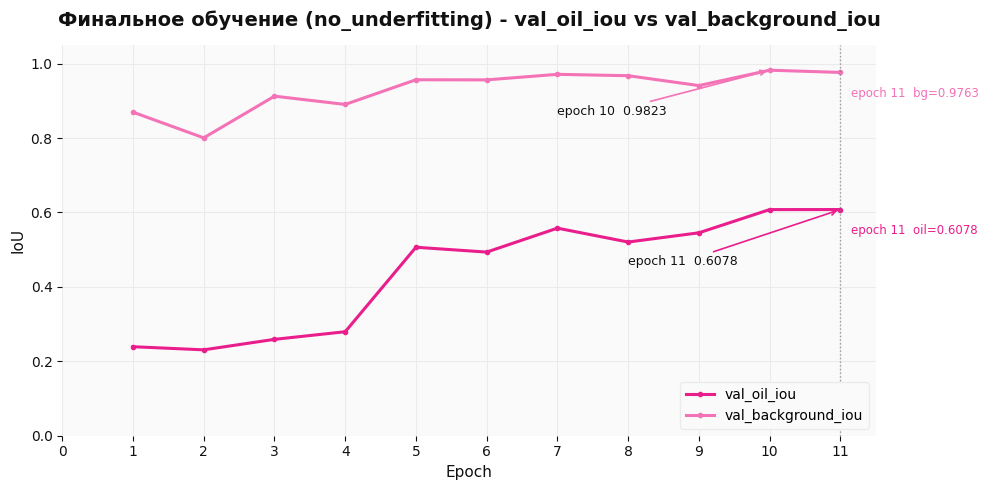

In [34]:
# График 8: Финальное обучение - val_oil_iou vs val_background_iou
epochs = list(range(1, 12))
val_oil_iou = [0.2392, 0.2308, 0.2590, 0.2795, 0.5065, 0.4935, 0.5578, 0.5205, 0.5453, 0.6077, 0.6078]
val_bg_iou  = [0.8695, 0.8005, 0.9125, 0.8903, 0.9566, 0.9563, 0.9712, 0.9675, 0.9410, 0.9823, 0.9763]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, val_oil_iou, color=C_PINK,      marker='o', markersize=3, label='val_oil_iou')
ax.plot(epochs, val_bg_iou,  color=C_PINK_SOFT, marker='o', markersize=3, label='val_background_iou')

# Лучшая эпоха по val_oil_iou
best_epoch_oil = val_oil_iou.index(max(val_oil_iou)) + 1
best_val_oil   = max(val_oil_iou)
ax.annotate(f'epoch {best_epoch_oil}  {best_val_oil:.4f}',
            xy=(best_epoch_oil, best_val_oil),
            xytext=(best_epoch_oil - 3, best_val_oil - 0.15),
            arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.2),
            fontsize=9, color=C_GRAY_DARK)

# Лучшая эпоха по val_background_iou
best_epoch_bg = val_bg_iou.index(max(val_bg_iou)) + 1
best_val_bg   = max(val_bg_iou)
ax.annotate(f'epoch {best_epoch_bg}  {best_val_bg:.4f}',
            xy=(best_epoch_bg, best_val_bg),
            xytext=(best_epoch_bg - 3, best_val_bg - 0.12),
            arrowprops=dict(arrowstyle='->', color=C_PINK_SOFT, lw=1.2),
            fontsize=9, color=C_GRAY_DARK)

ax.axvline(11, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)

ax.text(11.15, val_oil_iou[10] - 0.04,
        f'epoch 11  oil={val_oil_iou[10]:.4f}',
        fontsize=8.5, color=C_PINK, va='top')
ax.text(11.15, val_bg_iou[10] - 0.04,
        f'epoch 11  bg={val_bg_iou[10]:.4f}',
        fontsize=8.5, color=C_PINK_SOFT, va='top')

ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Финальное обучение (no_underfitting) - val_oil_iou vs val_background_iou')
ax.set_xticks(list(range(0, 12, 1)))
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('no_underfit_iou_curves.png')
plt.show()

На протяжении первых четырёх эпох модель **демонстрирует слабое качество сегментации нефтяного класса**: val_oil_iou не превышает 0,28, тогда как val_background_iou уже с первой эпохи держится выше 0,87. Начиная с пятой эпохи, происходит **резкий скачок val_oil_iou с 0,28 до 0,51**, что соответствует моменту, когда модель начинает уверенно распознавать нефтяные пиксели. К одиннадцатой эпохе val_oil_iou достигает 0,6078, val_background_iou - 0,9763. Устойчивый разрыв между двумя классами объясняется сильным дисбалансом классов в данных (-5% нефтяных пикселей), из-за которого фон значительно легче поддаётся сегментации.

## Блок 6. Составление тестового инвентаря и метрик scene

In [23]:
CHECKPOINT_PATH = Path('/kaggle/input/models/nd010604/best-model-unet-oil-spill-segmentation/pytorch/default/1/best_model.pth')
TEST_INV_PATH   = Path('/kaggle/working/test_patch_inventory.csv')
OUTPUT          = Path('/kaggle/working')

In [24]:
model = build_model()
ckpt  = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Модель загружена, эпоха:', ckpt['epoch'])

Модель загружена, эпоха: 11


In [25]:
def build_test_inventory(part3_root: Path, out_path: Path, patch_size: int = PATCH_SIZE) -> pd.DataFrame:
    img_root  = part3_root / 'Images'
    mask_root = part3_root / 'Mask'
    records   = []
    for cls in ['Oil', 'Lookalike', 'No oil']:
        img_files = sorted((img_root / cls).glob('*.tif'))
        print(f'[{cls}] найдено {len(img_files)} снимков')
        for img_path in tqdm(img_files, desc=cls):
            mask_path = mask_root / cls / f'{img_path.stem}_segmentation.tif'
            if not mask_path.exists():
                print(f'Маска не найдена для {img_path.name}, пропускаю')
                continue
            with rasterio.open(mask_path) as msrc:
                mask = msrc.read(1)
            H, W = mask.shape
            for row in range(0, H, patch_size):
                for col in range(0, W, patch_size):
                    pm = mask[row:row+patch_size, col:col+patch_size].astype('float32')
                    if pm.shape != (patch_size, patch_size):
                        pad = np.zeros((patch_size, patch_size), dtype='float32')
                        pad[:pm.shape[0], :pm.shape[1]] = pm
                        pm = pad
                    records.append(dict(
                        image_path=str(img_path),
                        mask_path=str(mask_path),
                        row=row, col=col,
                        has_oil=int(pm.max() > 0),
                        oil_frac=float(pm.mean()),
                    ))
    df = pd.DataFrame(records)
    df.to_csv(out_path, index=False)
    print(f'Тестовый инвентарь сохранён в {out_path}')
    print(f'Всего патчей: {len(df):,} | нефтяных: {df["has_oil"].sum():,} ({df["has_oil"].mean()*100:.1f}%)')
    return df

if TEST_INV_PATH.exists():
    print('Загружаю кэш тестового инвентаря')
    TEST_PATCH_INV = pd.read_csv(TEST_INV_PATH)
else:
    print('Строю тестовый инвентарь')
    TEST_PATCH_INV = build_test_inventory(Path(DATA_PARTS['part3']), TEST_INV_PATH)

print(f'Test: {len(TEST_PATCH_INV):,} патчей | нефтяных: {TEST_PATCH_INV["has_oil"].sum():,}')

Загружаю кэш тестового инвентаря
Test: 7,200 патчей | нефтяных: 1,072


In [26]:
# Патч-метрики
def evaluate_patch_metrics(inventory: pd.DataFrame, split_name: str) -> dict:
    dataset = OilSpillPatchDataset(inventory, NORM_STATS)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
    criterion = BCEDiceLoss()
    running_loss = sum_oil_iou = sum_bg_iou = sum_oil_dice = 0.0
    n = 0
    model.eval()
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc=f'patch [{split_name}]'):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            running_loss += criterion(logits, masks).item()
            m = compute_metrics(logits, masks)
            sum_oil_iou  += m['oil_iou']
            sum_bg_iou   += m['bg_iou']
            sum_oil_dice += m['oil_dice']
            n += 1
    return {
        f'{split_name}_loss':           running_loss / n,
        f'{split_name}_oil_iou':        sum_oil_iou  / n,
        f'{split_name}_background_iou': sum_bg_iou   / n,
        f'{split_name}_mean_iou':       (sum_oil_iou + sum_bg_iou) / (2 * n),
        f'{split_name}_oil_dice':       sum_oil_dice / n,
    }

In [27]:
# Scene-метрики
def compute_scene_metrics(inventory: pd.DataFrame, split_name: str) -> dict:
    full_size = 2048
    scene_ious, scene_dices = [], []
    model.eval()
    for img_path, group in tqdm(inventory.groupby('image_path'), desc=f'scene [{split_name}]'):
        pred_canvas = np.zeros((full_size, full_size), dtype=np.float32)
        mask_canvas = np.zeros((full_size, full_size), dtype=np.float32)
        for _, row in group.iterrows():
            window = Window(int(row['col']), int(row['row']), PATCH_SIZE, PATCH_SIZE)
            with rasterio.open(row['image_path']) as src:
                img = src.read(window=window).astype('float32')
            with rasterio.open(row['mask_path']) as src:
                mask = src.read(1, window=window).astype('float32')
            c, h, w = img.shape
            if h != PATCH_SIZE or w != PATCH_SIZE:
                pi = np.zeros((c, PATCH_SIZE, PATCH_SIZE), dtype='float32')
                pm = np.zeros((PATCH_SIZE, PATCH_SIZE),    dtype='float32')
                pi[:, :h, :w] = img
                pm[:h, :w]    = mask
                img, mask = pi, pm
            img[0] = (img[0] - NORM_STATS['vv_mean']) / NORM_STATS['vv_std']
            img[1] = (img[1] - NORM_STATS['vh_mean']) / NORM_STATS['vh_std']
            image_t = torch.from_numpy(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                prob = torch.sigmoid(model(image_t)).squeeze().cpu().numpy()
            r, c_ = int(row['row']), int(row['col'])
            ph = min(PATCH_SIZE, full_size - r)
            pw = min(PATCH_SIZE, full_size - c_)
            pred_canvas[r:r+ph, c_:c_+pw] = prob[:ph, :pw]
            mask_canvas[r:r+ph, c_:c_+pw] = mask[:ph, :pw]
        pred_bin = (pred_canvas > 0.5).astype(np.float32)
        inter = (pred_bin * mask_canvas).sum()
        union = pred_bin.sum() + mask_canvas.sum() - inter
        denom = pred_bin.sum() + mask_canvas.sum()
        scene_ious.append(float((inter + 1e-7) / (union + 1e-7)))
        scene_dices.append(float((2.0 * inter + 1e-7) / (denom + 1e-7)))
    torch.cuda.empty_cache()
    gc.collect()
    return {
        f'{split_name}_scene_oil_iou':  float(np.mean(scene_ious)),
        f'{split_name}_scene_oil_dice': float(np.mean(scene_dices)),
    }

In [28]:
val_df = pd.read_csv(VAL_CSV)

print('\n── Валидация ──')
val_metrics = {
    **evaluate_patch_metrics(val_df,       'val'),
    **compute_scene_metrics(val_df,        'val'),
}

print('\n── Тест ──')
test_metrics = {
    **evaluate_patch_metrics(TEST_PATCH_INV, 'test'),
    **compute_scene_metrics(TEST_PATCH_INV,  'test'),
}

print('\n── Результаты ──')
for k, v in {**val_metrics, **test_metrics}.items():
    print(f'{k}: {v:.4f}')


── Валидация ──


patch [val]:   0%|          | 0/1028 [00:00<?, ?it/s]

scene [val]:   0%|          | 0/514 [00:00<?, ?it/s]


── Тест ──


patch [test]:   0%|          | 0/900 [00:00<?, ?it/s]

scene [test]:   0%|          | 0/450 [00:00<?, ?it/s]


── Результаты ──
val_loss: 0.2293
val_oil_iou: 0.6078
val_background_iou: 0.9763
val_mean_iou: 0.7920
val_oil_dice: 0.6574
val_scene_oil_iou: 0.5629
val_scene_oil_dice: 0.6194
test_loss: 1.5884
test_oil_iou: 0.6440
test_background_iou: 0.9379
test_mean_iou: 0.7909
test_oil_dice: 0.6785
test_scene_oil_iou: 0.5910
test_scene_oil_dice: 0.6333


In [29]:
torch.cuda.empty_cache()
gc.collect()

0

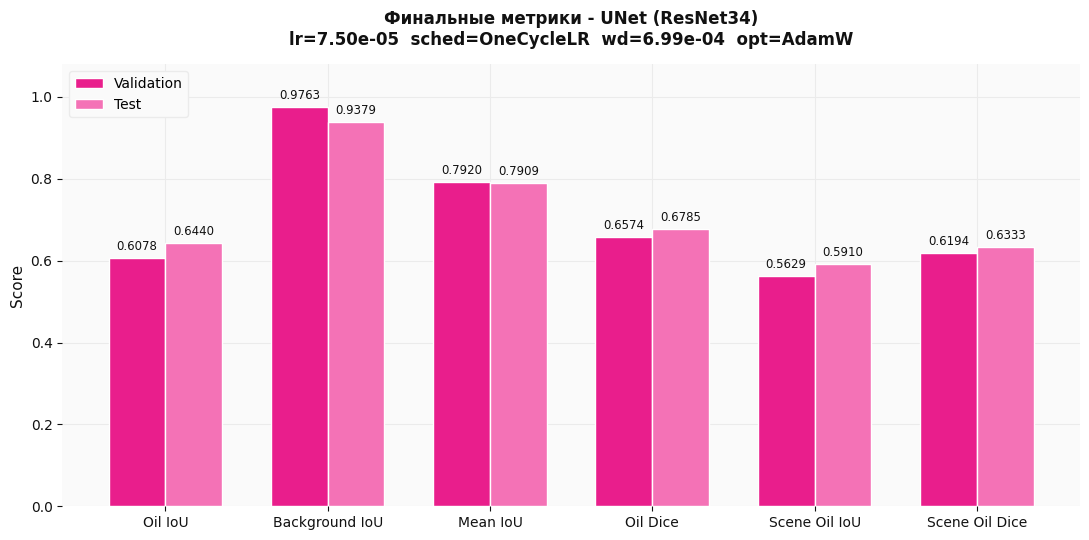

In [29]:
# график 9: Финальные метрики UNet
metrics_labels = ['Oil IoU', 'Background IoU', 'Mean IoU', 'Oil Dice', 'Scene Oil IoU', 'Scene Oil Dice']
val_values  = [0.6078, 0.9763, 0.7920, 0.6574, 0.5629, 0.6194]
test_values = [0.6440, 0.9379, 0.7909, 0.6785, 0.5910, 0.6333]

WINNER_CONFIG = dict(lr=0.000075, scheduler='OneCycleLR', weight_decay=0.000699, optimizer='AdamW')

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
bars_val  = ax.bar(x - width/2, val_values,  width, color=C_PINK,      edgecolor='white', label='Validation', zorder=3)
bars_test = ax.bar(x + width/2, test_values, width, color=C_PINK_SOFT, edgecolor='white', label='Test',       zorder=3)

for bars in (bars_val, bars_test):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.012,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=8.5, color=C_GRAY_DARK)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title(
    f'Финальные метрики - UNet (ResNet34)\n'
    f'lr={WINNER_CONFIG["lr"]:.2e}  sched={WINNER_CONFIG["scheduler"]}  '
    f'wd={WINNER_CONFIG["weight_decay"]:.2e}  opt={WINNER_CONFIG["optimizer"]}',
    fontsize=12,
)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('final_summary_metrics_unet.png')
plt.show()

**Финальные метрики модели UNet (ResNet34, Config B: AdamW + OneCycleLR)**

На уровне патчей модель демонстрирует стабильные результаты: val_oil_iou составляет 0,6078, test_oil_iou - 0,6440, что свидетельствует об отсутствии переобучения и хорошей обобщающей способности модели. Background IoU ожидаемо высокий на обеих выборках (0,9763 и 0,9379 соответственно) - фоновый класс значительно проще для сегментации ввиду его доминирования в данных (98% пикселей).

На уровне сцен метрики закономерно снижаются: scene_oil_iou составляет 0,5629 на валидации и 0,5910 на тесте. Это объясняется тем, что при сшивке патчей 512×512 в полный снимок 2048×2048 граничные эффекты между патчами и редкие мелкие разливы нефти вносят дополнительные ошибки, которые не видны на уровне отдельных патчей. Тем не менее незначительное превосходство тестовых метрик над валидационными на обоих уровнях говорит о том, что модель не переобучилась под валидационную выборку.

Веса модели: https://www.kaggle.com/datasets/daryanikitina/unet-resnet34-oil-spill-sar-segmentation 

## Блок 7. Подбор threshold для веб-демонстрации

thr=0.10  oil_iou=0.3128  oil_dice=0.4765
thr=0.15  oil_iou=0.3248  oil_dice=0.4903
thr=0.20  oil_iou=0.3346  oil_dice=0.5014
thr=0.25  oil_iou=0.3434  oil_dice=0.5112
thr=0.30  oil_iou=0.3518  oil_dice=0.5205
thr=0.35  oil_iou=0.3602  oil_dice=0.5296
thr=0.40  oil_iou=0.3688  oil_dice=0.5388
thr=0.45  oil_iou=0.3779  oil_dice=0.5485
thr=0.50  oil_iou=0.3877  oil_dice=0.5588
thr=0.55  oil_iou=0.3986  oil_dice=0.5700
thr=0.60  oil_iou=0.4107  oil_dice=0.5823
thr=0.65  oil_iou=0.4242  oil_dice=0.5957
thr=0.70  oil_iou=0.4395  oil_dice=0.6106
thr=0.75  oil_iou=0.4566  oil_dice=0.6269
thr=0.80  oil_iou=0.4764  oil_dice=0.6453
thr=0.85  oil_iou=0.5015  oil_dice=0.6680
thr=0.90  oil_iou=0.5378  oil_dice=0.6994

Лучший порог по IoU:  0.90  → 0.5378
Лучший порог по Dice: 0.90  → 0.6994


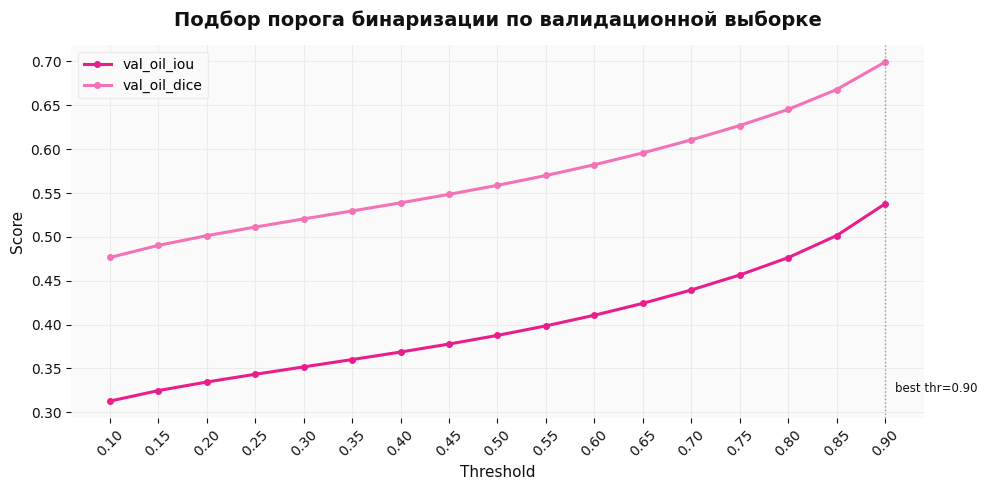

In [30]:
thresholds  = np.arange(0.1, 0.91, 0.05)
iou_scores  = []
dice_scores = []

val_df  = pd.read_csv(VAL_CSV)
dataset = OilSpillPatchDataset(val_df, NORM_STATS)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

eps = 1e-7
model.eval()

for thr in thresholds:
    total_inter = total_union = total_denom = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > thr).float()
            inter = (preds * masks).sum().item()
            union = (preds.sum() + masks.sum() - (preds * masks).sum()).item()
            total_inter += inter
            total_union += union
            total_denom += preds.sum().item() + masks.sum().item()
    iou  = (total_inter + eps) / (total_union + eps)
    dice = (2 * total_inter + eps) / (total_denom + eps)
    iou_scores.append(iou)
    dice_scores.append(dice)
    print(f'thr={thr:.2f}  oil_iou={iou:.4f}  oil_dice={dice:.4f}')

best_thr_iou  = thresholds[np.argmax(iou_scores)]
best_thr_dice = thresholds[np.argmax(dice_scores)]
print(f'\nЛучший порог по IoU:  {best_thr_iou:.2f}  → {max(iou_scores):.4f}')
print(f'Лучший порог по Dice: {best_thr_dice:.2f}  → {max(dice_scores):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, iou_scores,  color=C_PINK,      marker='o', markersize=4, label='val_oil_iou')
ax.plot(thresholds, dice_scores, color=C_PINK_SOFT, marker='o', markersize=4, label='val_oil_dice')
ax.axvline(best_thr_iou, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(best_thr_iou + 0.01, min(iou_scores) + 0.01,
        f'best thr={best_thr_iou:.2f}', fontsize=8.5, color=C_GRAY_DARK)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Подбор порога бинаризации по валидационной выборке')
ax.set_xticks(np.round(thresholds, 2))
ax.tick_params(axis='x', rotation=45)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig('threshold_search.png')
plt.show()

thr=0.10  iou=0.3128  dice=0.4765  f2=0.6802  prec=0.3179  rec=0.9511
thr=0.15  iou=0.3248  dice=0.4903  f2=0.6902  prec=0.3307  rec=0.9477
thr=0.20  iou=0.3346  dice=0.5014  f2=0.6979  prec=0.3412  rec=0.9448
thr=0.25  iou=0.3434  dice=0.5112  f2=0.7045  prec=0.3508  rec=0.9420
thr=0.30  iou=0.3518  dice=0.5205  f2=0.7106  prec=0.3600  rec=0.9393
thr=0.35  iou=0.3602  dice=0.5296  f2=0.7164  prec=0.3692  rec=0.9365
thr=0.40  iou=0.3688  dice=0.5388  f2=0.7220  prec=0.3787  rec=0.9337
thr=0.45  iou=0.3779  dice=0.5485  f2=0.7278  prec=0.3888  rec=0.9306
thr=0.50  iou=0.3877  dice=0.5588  f2=0.7337  prec=0.3999  rec=0.9273
thr=0.55  iou=0.3986  dice=0.5700  f2=0.7399  prec=0.4122  rec=0.9235
thr=0.60  iou=0.4107  dice=0.5823  f2=0.7464  prec=0.4261  rec=0.9192
thr=0.65  iou=0.4242  dice=0.5957  f2=0.7531  prec=0.4419  rec=0.9141
thr=0.70  iou=0.4395  dice=0.6106  f2=0.7600  prec=0.4599  rec=0.9081
thr=0.75  iou=0.4566  dice=0.6269  f2=0.7667  prec=0.4809  rec=0.9005
thr=0.80  iou=0.4764

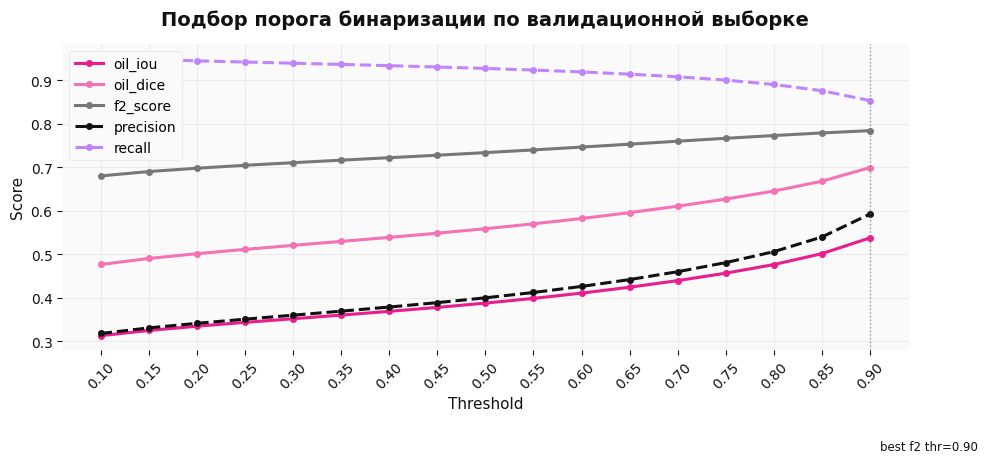

In [32]:
thresholds  = np.arange(0.1, 0.91, 0.05)
iou_scores  = []
dice_scores = []
f2_scores   = []
precisions  = []
recalls     = []

val_df  = pd.read_csv(VAL_CSV)
dataset = OilSpillPatchDataset(val_df, NORM_STATS)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

eps = 1e-7
model.eval()

for thr in thresholds:
    total_inter = total_union = total_denom = 0.0
    total_tp = total_fp = total_fn = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > thr).float()
            inter = (preds * masks).sum().item()
            union = (preds.sum() + masks.sum() - (preds * masks).sum()).item()
            total_inter += inter
            total_union += union
            total_denom += preds.sum().item() + masks.sum().item()
            total_tp += inter
            total_fp += (preds * (1 - masks)).sum().item()
            total_fn += ((1 - preds) * masks).sum().item()

    iou       = (total_inter + eps) / (total_union + eps)
    dice      = (2 * total_inter + eps) / (total_denom + eps)
    precision = (total_tp + eps) / (total_tp + total_fp + eps)
    recall    = (total_tp + eps) / (total_tp + total_fn + eps)
    f2        = (5 * precision * recall + eps) / (4 * precision + recall + eps)

    iou_scores.append(iou)
    dice_scores.append(dice)
    f2_scores.append(f2)
    precisions.append(precision)
    recalls.append(recall)

    print(f'thr={thr:.2f}  iou={iou:.4f}  dice={dice:.4f}  f2={f2:.4f}  prec={precision:.4f}  rec={recall:.4f}')

best_thr_iou = thresholds[np.argmax(iou_scores)]
best_thr_f2  = thresholds[np.argmax(f2_scores)]
print(f'\nЛучший порог по IoU: {best_thr_iou:.2f}  → {max(iou_scores):.4f}')
print(f'Лучший порог по F2:  {best_thr_f2:.2f}   → {max(f2_scores):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, iou_scores,  color=C_PINK,      marker='o', markersize=4, label='oil_iou')
ax.plot(thresholds, dice_scores, color=C_PINK_SOFT, marker='o', markersize=4, label='oil_dice')
ax.plot(thresholds, f2_scores,   color=C_GRAY,      marker='o', markersize=4, label='f2_score')
ax.plot(thresholds, precisions,  color=C_GRAY_DARK, marker='o', markersize=4, linestyle='--', label='precision')
ax.plot(thresholds, recalls, color='#c084fc', marker='o', markersize=4, linestyle='--', label='recall')
ax.axvline(best_thr_f2, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(best_thr_f2 + 0.01, 0.05, f'best f2 thr={best_thr_f2:.2f}', fontsize=8.5, color=C_GRAY_DARK)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Подбор порога бинаризации по валидационной выборке')
ax.set_xticks(np.round(thresholds, 2))
ax.tick_params(axis='x', rotation=45)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig('threshold_search.png')
plt.show()

thr=0.90  iou=0.5378  dice=0.6994  f2=0.7842  prec=0.5926  rec=0.8532
thr=0.91  iou=0.5465  dice=0.7067  f2=0.7846  prec=0.6065  rec=0.8467
thr=0.92  iou=0.5555  dice=0.7143  f2=0.7843  prec=0.6217  rec=0.8392
thr=0.93  iou=0.5648  dice=0.7219  f2=0.7833  prec=0.6385  rec=0.8303
thr=0.94  iou=0.5741  dice=0.7294  f2=0.7808  prec=0.6573  rec=0.8193
thr=0.95  iou=0.5831  dice=0.7367  f2=0.7763  prec=0.6789  rec=0.8052
thr=0.96  iou=0.5915  dice=0.7434  f2=0.7685  prec=0.7050  rec=0.7861
thr=0.97  iou=0.5977  dice=0.7482  f2=0.7546  prec=0.7377  rec=0.7589
thr=0.98  iou=0.5947  dice=0.7459  f2=0.7282  prec=0.7774  rec=0.7168
thr=0.99  iou=0.5614  dice=0.7191  f2=0.6662  prec=0.8290  rec=0.6350

Лучший порог по IoU: 0.97  → 0.5977
Лучший порог по F2:  0.91   → 0.7846


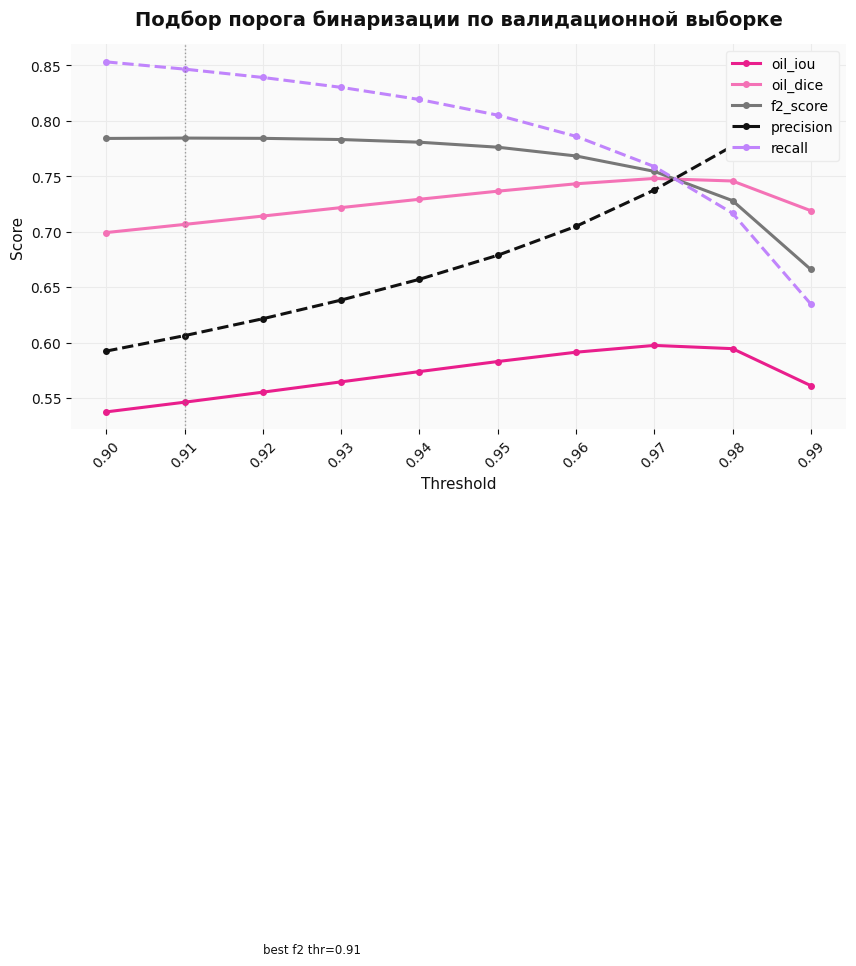

In [35]:
thresholds = np.arange(0.90, 0.995, 0.01)
iou_scores  = []
dice_scores = []
f2_scores   = []
precisions  = []
recalls     = []

val_df  = pd.read_csv(VAL_CSV)
dataset = OilSpillPatchDataset(val_df, NORM_STATS)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

eps = 1e-7
model.eval()

for thr in thresholds:
    total_inter = total_union = total_denom = 0.0
    total_tp = total_fp = total_fn = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > thr).float()
            inter = (preds * masks).sum().item()
            union = (preds.sum() + masks.sum() - (preds * masks).sum()).item()
            total_inter += inter
            total_union += union
            total_denom += preds.sum().item() + masks.sum().item()
            total_tp += inter
            total_fp += (preds * (1 - masks)).sum().item()
            total_fn += ((1 - preds) * masks).sum().item()

    iou       = (total_inter + eps) / (total_union + eps)
    dice      = (2 * total_inter + eps) / (total_denom + eps)
    precision = (total_tp + eps) / (total_tp + total_fp + eps)
    recall    = (total_tp + eps) / (total_tp + total_fn + eps)
    f2        = (5 * precision * recall + eps) / (4 * precision + recall + eps)

    iou_scores.append(iou)
    dice_scores.append(dice)
    f2_scores.append(f2)
    precisions.append(precision)
    recalls.append(recall)

    print(f'thr={thr:.2f}  iou={iou:.4f}  dice={dice:.4f}  f2={f2:.4f}  prec={precision:.4f}  rec={recall:.4f}')

best_thr_iou = thresholds[np.argmax(iou_scores)]
best_thr_f2  = thresholds[np.argmax(f2_scores)]
print(f'\nЛучший порог по IoU: {best_thr_iou:.2f}  → {max(iou_scores):.4f}')
print(f'Лучший порог по F2:  {best_thr_f2:.2f}   → {max(f2_scores):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, iou_scores,  color=C_PINK,      marker='o', markersize=4, label='oil_iou')
ax.plot(thresholds, dice_scores, color=C_PINK_SOFT, marker='o', markersize=4, label='oil_dice')
ax.plot(thresholds, f2_scores,   color=C_GRAY,      marker='o', markersize=4, label='f2_score')
ax.plot(thresholds, precisions,  color=C_GRAY_DARK, marker='o', markersize=4, linestyle='--', label='precision')
ax.plot(thresholds, recalls, color='#c084fc', marker='o', markersize=4, linestyle='--', label='recall')
ax.axvline(best_thr_f2, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(best_thr_f2 + 0.01, 0.05, f'best f2 thr={best_thr_f2:.2f}', fontsize=8.5, color=C_GRAY_DARK)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Подбор порога бинаризации по валидационной выборке')
ax.set_xticks(np.round(thresholds, 2))
ax.tick_params(axis='x', rotation=45)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig('threshold_search_90+.png')
plt.show()

### Выбор порога бинаризации: 0.91

Перебор порогов от 0.90 до 0.99 даёт два разных оптимума: IoU максимален при `thr=0.97` (0.5977), а F2-мера при `thr=0.91` (0.7846). Расхождение объясняется тем, что F2 взвешивает recall в 4 раза сильнее precision, тогда как IoU балансирует их симметрично.

Для задачи детекции разливов цена ошибок асимметрична: пропуск разлива (false negative) даёт расползание необнаруженного загрязнения и накопление ущерба, тогда как ложное срабатывание (false positive) стоит лишь нескольких минут проверки оператором. Это не критическая асимметрия как в медицинской диагностике, но она достаточна, чтобы сознательно сместить порог в сторону recall.

**Итог:** выбран порог **0.91** (оптимальный по F2). Это даёт recall 0.8467 против 0.7589 на `thr=0.97` - модель находит на 9 п.п. больше реальных разливов, уступая в precision (0.6065 против 0.7377) и в IoU (0.5465 против 0.5977). Эта потеря в формальной метрике сегментации принята осознанно как компромисс в пользу домен-специфичного приоритета.